# 🧠🤝👐 Semantic & Gesture Representation Extraction and Analysis

The notebook walks you through:

1. **Extracting sentence-level text-based semantic embeddings** (Dutch BERT 💬).
2. **Encoding iconic gesture strokes with a self-supervised skeleton model** (👐).
3. **Analysing cosine-similarity patterns within and across dialogues using semantic and gesture embeddings** (🧠🤝).
4. **Comparing visibility conditions** — what changes when interlocutors cannot see each other (🎥 vs 🎧)?

Point 3 is based on the similarity analysis in [Ghaleb et al. (2024)-ICMI:
**Learning Co-Speech Gesture Representations in Dialogue through Contrastive Learning: An Intrinsic Evaluation**](https://arxiv.org/pdf/2409.10535).
It uses cosine similarity between learned embeddings to evaluate the similarity of gestures based on their
semantic content and form features, and follows the intrinsic-evaluation recipe of that paper, where cosine
similarity between learned embeddings correlated positively with the number of shared form features (ρ≈0.31).

This tutorial is based on video-mediated (Zoom) dialogues: [Sho Akamine et al. (2026), *Lexical alignment and speaker visibility influence gestural alignment in conversation: Implications for theories of linguistic alignment*](https://osf.io/preprints/psyarxiv/kjhd2_v1)

Point 4 is what this dataset adds on top of the face-to-face dataset because visibility was manipulated
between dyads, we can ask whether the *dialogue-driven* similarity we observe survives when the partner's
gestures are invisible.

## 📑 Notebook overview

1. **⚙️ Environment setup** — install & import libraries, set paths

2. **1️⃣ Data & preliminaries** — read ELAN annotations, poses & transcripts

3. **2️⃣ Sentence embeddings 💬** — Dutch BERT mean-pooling

4. **3️⃣ Gesture embeddings 👐** — Multimodal-X skeleton encoder

5. **4️⃣ Similarity analysis 🔍** — intrinsic evaluation, pair types

6. **5️⃣ Speaker-level analysis** — referent effects within a speaker

7. **6️⃣ Dialogue-level analysis** — speaker ✕ referent effects

8. **7️⃣ Cross-dialogue analysis** — referent vs. interaction driven similarity

9. **8️⃣ Distribution view (KDE)** — the same contrasts as full distributions

10. **9️⃣ Visibility conditions 🎥🎧** — Sym vs. AO, and similarity across rounds

11. **📝 Exercise** — try different embedding modalities and conditions

## ⚙️ Environment setup

Import common libraries. The local helper modules (`model/`, `dialog_utils/`, `utils/`) are the same ones
that ship with the face-to-face tutorial — only the *data-reading* code below is specific to the Zoom corpus.

In [1]:
import os, sys, glob, ast, json, pathlib, itertools, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np, pandas as pd, torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_ind, spearmanr, pearsonr

# Add project root and model directory to sys.path to resolve internal sub-module imports
project_root = Path.cwd()
for p in [project_root, project_root / "model"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from transformers import AutoTokenizer, AutoModel
import gdown
import pympi          # reading ELAN (.eaf) annotation files
import spacy          # lemmatisation / PoS tagging of the transcripts

# Local helpers -------------------------------------------------------
from model.skeleton_speech_models import GSSModel

# statannotations is only used to draw the significance brackets; the notebook
# falls back to its own Welch-test annotations when it is not installed.
try:
    from statannotations.Annotator import Annotator
    HAS_STATANNOT = True
except Exception:
    HAS_STATANNOT = False
    print("statannotations not found -> using the built-in Welch-test annotations.")

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

/opt/anaconda3/envs/test2/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Device: cpu


In [2]:
# I use these commands to make the notebook interactive and automatically reload modified modules)
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
# set the colors and seaborn style
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='Paired', font_scale=1.2)

# seaborn changed the bar-plot error-bar argument in 0.12
_SNS_VERSION = tuple(int(v) for v in sns.__version__.split(".")[:2])
BAR_ERR_KW = {"errorbar": ("ci", 95)} if _SNS_VERSION >= (0, 12) else {"ci": 95}

### 🔧 Configuration

Everything that depends on *where your copy of the corpus lives* is collected here, together with the
switches that control how heavy the notebook is. The most important one is `USE_CACHE`: extracting
embeddings for all iconic gestures takes a while, so the notebook writes a pickle once and re-uses it
afterwards. Delete the pickle (or set `USE_CACHE = False`) to re-run the full extraction.

In [70]:
# ------------------------------------------------------------------ paths
DATA_ROOT            = Path("data/technology_mediated_interaction")
ELAN_DIR             = DATA_ROOT / "01_ELAN"                       # *.eaf gesture/round/trial annotations
POSE_GLOB            = str(DATA_ROOT / "02_mmpose" / "*.npy")      # per-participant MMPose keypoints
PARTICIPANT_INFO_CSV = DATA_ROOT / "participant_info_to_share.csv" # pair, speaker, condition, demographics
ALIGNED_SPEECH_CSV   = ELAN_DIR / "tm_interaction_aligned.csv"     # WhisperX word-level transcripts
CACHE_PKL            = DATA_ROOT / "processed_gestures_iconicity_with_semantic_and_gesture_all_embeddings.pkl"

# ------------------------------------------------------------------ recording / encoder settings
FPS              = 50    # the Zoom recordings are 50 fps (the face-to-face CABB videos were ~30 fps)
FRAME_STEP       = 2     # 50 fps -> 25 fps, the rate the gesture encoder was trained on
MAX_CLIP_FRAMES  = 60    # the encoder consumes at most 60 frames (~2.4 s at 25 fps)
MIN_CLIP_FRAMES  = 8     # shorter strokes are padded by repeating the last frame
SPEECH_BUFFER_S  = 0.5   # words this far around a stroke count as co-occurring speech

# ------------------------------------------------------------------ analysis settings
RANDOM_STATE        = 42
MAX_GESTURES        = None #5000     # gestures kept for the pairwise analysis (None = all; ~7.5k -> ~28M pairs)
MAX_PAIRS_PER_TYPE  = None #50_000   # rows kept per pair type (None = all)
CONDITIONS          = ["Sym", "AO"]   # visibility conditions to compare ("Asym" is also in the corpus)
REFERENCE_CONDITION = "Sym"           # the condition used for the ICMI-style analyses (§5–§8)

USE_CACHE = True
REBUILD   = not (USE_CACHE and CACHE_PKL.exists())

print(f"cache file : {CACHE_PKL}")
print(f"exists     : {CACHE_PKL.exists()}")
print(f"REBUILD    : {REBUILD}  ->  " +
      ("the notebook will read the raw ELAN/pose/transcript files and extract embeddings."
       if REBUILD else "the notebook will load the pre-computed table and go straight to the analysis."))

cache file : data/technology_mediated_interaction/processed_gestures_iconicity_with_semantic_and_gesture_all_embeddings.pkl
exists     : True
REBUILD    : False  ->  the notebook will load the pre-computed table and go straight to the analysis.


## 1️⃣ Data & preliminaries

**The corpus.** 45 Dutch-speaking dyads performed a *director–matcher* repeated referential game over Zoom,
describing 16 Fribbles (novel 3-D objects made of a main body and 3–6 subparts) across 96 trials
(16 trials × 6 rounds), alternating roles after every trial. Video was recorded at **50 fps**; speech was
transcribed with **WhisperX** and hand-corrected; gesture **strokes** were segmented in ELAN and coded for
iconicity, deixis, beat and pragmatic function, and every iconic gesture received a **referent** label
pointing at a Fribble subpart (e.g. `09C` → Fribble 09, subpart C).

**Mutual visibility was manipulated *between* dyads**:

| Condition | Cameras | Who sees whose gestures | Mechanisms available |
|-----------|---------|-------------------------|----------------------|
| **SymAV** (`Sym`) | both on | both partners | priming **and** grounding |
| **AsymAV** (`Asym`) | only A's on | B sees A, A does not see B | priming for B only |
| **AO** | both off | neither | neither |

This gives us a built-in control: any similarity between the gestures of two interlocutors in the **AO**
condition cannot come from seeing each other.

The cells below read four things per dyad: the **ELAN tiers**, the **MMPose keypoints**
(27 upper-body/hand joints), the **participant table** (which carries the condition), and the
**word-level transcripts**.

In [5]:
def load_keypoints_dict(pose_glob=POSE_GLOB):
    """Load one 2-D pose array per participant.

    Each file holds the MMPose output for a single participant of a single dyad,
    with shape ``(T, V, C)`` = (frames, 27 selected joints, [x, y, confidence]).
    The key is the ``participant_id`` (e.g. ``019_a``) used in the gesture table.
    """
    keypoints = {}
    for file in sorted(glob.glob(pose_glob)):
        name = Path(file).name
        for junk in ["_selected_keypoints.npy", ".npy", "results_"]:
            name = name.replace(junk, "")
        keypoints[name] = np.load(file)
    return keypoints

### ⚙️ Read the gesture annotations

Every `.eaf` file contains, per dyad:

* `round`, `trial`, `director` — the task structure (which round/trial, and who was describing),
* `{A,B}_{LH,RH}_gesture` — the segmented strokes of each hand of each speaker,
* `{...}_iconicity | _deixis | _beat | _pragmaticality` — the semiotic dimensions of each stroke,
* `{...}_referent` — the Fribble subpart the gesture refers to.

Because the tiers are aligned in milliseconds, we convert to frame indices with the recording's 50 fps.

In [6]:
GESTURE_TYPES = ["iconicity", "deixis", "beat", "pragmaticality"]
TOL_MS = 10   # tolerance when matching a stroke to the round/trial/director intervals

def ms_to_frame(t_ms, fps=FPS):
    """Convert a timestamp in ms to a 0-based frame index."""
    return int(t_ms / (1000.0 / fps))

def assign_interval_label(start, end, intervals, tol=TOL_MS):
    """Return the label of the interval that (tolerantly) contains [start, end]."""
    for t_start, t_end, label in intervals:
        if (start >= t_start - tol) and (end <= t_end + tol):
            return label
    return None

def tier_data(eaf, tier_name):
    """Annotations of one ELAN tier, or an empty list when the tier is absent."""
    try:
        return eaf.get_annotation_data_for_tier(tier_name)
    except Exception:
        return []

def read_gesture_annotations(elan_dir=ELAN_DIR, fps=FPS):
    """Read every ELAN file in `elan_dir` into one long gesture table."""
    rows = []
    eaf_files = sorted(f for f in os.listdir(elan_dir) if f.endswith(".eaf"))
    for f in tqdm(eaf_files, desc="Reading ELAN files"):
        eaf = pympi.Elan.Eaf(str(Path(elan_dir) / f))
        rounds    = tier_data(eaf, "round")
        trials    = tier_data(eaf, "trial")
        directors = tier_data(eaf, "director")
        pair_id   = f.replace(".eaf", "")

        for speaker in ["A", "B"]:
            for tier in [f"{speaker}_LH_gesture", f"{speaker}_RH_gesture"]:
                gesture_data = tier_data(eaf, tier)
                if not gesture_data:
                    continue

                # semiotic dimensions: {(start, end)} per dimension
                type_times = {
                    g_type: {(s, e) for s, e, *_ in tier_data(eaf, f"{tier}_{g_type}")}
                    for g_type in GESTURE_TYPES
                }
                referent_times = {
                    (s, e): str(ref).strip()
                    for s, e, ref, *_ in tier_data(eaf, f"{tier}_referent")
                }

                for start, end, gesture in gesture_data:
                    gesture = gesture.strip()
                    if gesture == "undecided" or "non-gesture" in gesture:
                        continue

                    subtype = "other"
                    for g_type, times in type_times.items():
                        if (start, end) in times:
                            subtype = g_type
                            break

                    rows.append({
                        "pair_id":        pair_id,
                        "speaker":        speaker,
                        "tier":           tier,
                        "round":          assign_interval_label(start, end, rounds),
                        "trial":          assign_interval_label(start, end, trials),
                        "is_director":    assign_interval_label(start, end, directors) == speaker,
                        "start_frame":    ms_to_frame(start, fps),
                        "end_frame":      ms_to_frame(end, fps),
                        "start_time":     start / 1000.0,
                        "end_time":       end / 1000.0,
                        "gesture":        subtype,
                        "referent":       referent_times.get((start, end), None),
                        "participant_id": f"{pair_id}_{speaker.lower()}",
                    })
    return pd.DataFrame(rows)

### 🏷️ Clean the referent labels

Referents were annotated as Fribble subparts, sometimes with coding suffixes (`-REP`, `-WF`), sometimes
with two referents in one label (`11B+11D`). We follow the cleaning used in Ghaleb et al. (2024, §3.2):
strip the suffixes, explode multi-referent labels into separate rows, and normalise everything to
`<letter><two digits>` (so `9c` and `09C` both become `C09`).

In [7]:
def pad_referent(ref: str) -> str:
    """Normalise a referent label to <LETTERS><zero-padded digits>, e.g. '9c' -> 'C09'."""
    ref = str(ref).upper()
    if any(ch.isalpha() for ch in ref):
        letters = "".join(filter(str.isalpha, ref))
        digits  = "".join(filter(str.isdigit, ref)).zfill(2)
        return letters + digits
    return ref.zfill(2) if ref.isdigit() else ref

def clean_referent_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Keep iconic gestures and turn the raw referent annotation into a clean label."""
    out = df[df["gesture"] == "iconicity"].reset_index(drop=True).copy()
    out["referent"] = out["referent"].astype(str)

    # drop coding suffixes such as -REP / -WF
    suffixes = ("-REP", "-rep", "-WF", "-wf", "ref", "REF")
    out["referent_clean"] = out["referent"].apply(
        lambda x: x if not x.endswith(suffixes) else x.split("-")[0])

    # one row per referent when a gesture depicts two subparts (e.g. '11B+11D')
    out["referent_clean"] = out["referent_clean"].str.replace(" ", "", regex=False)
    out = out.assign(referent_clean=out["referent_clean"].str.split("+")).explode("referent_clean")

    out["referent_clean"] = (out["referent_clean"].str.replace("-", "0", regex=False)
                                                  .str.replace("'", "", regex=False))
    # conventional codes used by the annotators
    out["referent_clean"] = out["referent_clean"].apply(
        lambda x: "17" if "general" in x else ("0" if "main" in x else x))
    out = out[~out["referent_clean"].isin(["undecided", "None", "nan", ""])]

    out["referent_clean"] = out["referent_clean"].map(pad_referent)
    out = out[~out["referent_clean"].isin(["OTHER00", "00"])]
    out = out[out["referent_clean"].str.contains(r"[A-Z]", na=False)]

    out["referent"] = out["referent_clean"]
    out["object"] = out["referent_clean"]
    return out.reset_index(drop=True)

### 👥 Attach the participant table (this is where the visibility condition comes from)

In [8]:
CONDITION_ALIASES = {
    "sym": "Sym", "symav": "Sym", "symmetric": "Sym", "symmetrical": "Sym",
    "asym": "Asym", "asymav": "Asym", "asymmetric": "Asym", "asymmetrical": "Asym",
    "ao": "AO", "audio": "AO", "audioonly": "AO", "audio-only": "AO", "auditory-only": "AO",
}

def normalize_condition(value):
    """Map the many spellings of the visibility conditions onto Sym / Asym / AO."""
    if pd.isna(value):
        return np.nan
    key = str(value).strip().lower().replace(" ", "").replace("_", "")
    return CONDITION_ALIASES.get(key, str(value).strip())

def attach_participant_info(df: pd.DataFrame, csv=PARTICIPANT_INFO_CSV) -> pd.DataFrame:
    """Merge the per-participant metadata (visibility condition, demographics) into the gesture table."""
    info = pd.read_csv(csv)
    # the condition column is spelled differently in different releases of the table
    condition_col = next((c for c in info.columns if "cond" in c.lower()), None)
    if condition_col is None:
        raise KeyError(f"No condition column found in {csv}. Columns: {list(info.columns)}")
    info = info.rename(columns={condition_col: "Condition"})

    out = df.copy()
    out["Pair"] = out["pair_id"].apply(lambda x: int("".join(filter(str.isdigit, str(x)))))
    out["Speaker"] = out["speaker"].str.upper()
    out = out.merge(info, on=["Pair", "Speaker"], how="left")
    out["Condition"] = out["Condition"].map(normalize_condition)

    missing = out["Condition"].isna().sum()
    if missing:
        print(f"[!] {missing} gestures could not be matched to the participant table "
              f"(check the Pair/Speaker columns in {csv.name}).")
    return out

### 💬 Attach the co-occurring speech

WhisperX gives us word-level timestamps. For every gesture stroke we take the words that fall inside the
stroke window widened by `SPEECH_BUFFER_S`, and lemmatise them with spaCy — the lemmas are what the
sentence encoder sees, exactly as in the face-to-face tutorial.

In [9]:
def load_spacy_model():
    """Dutch spaCy model, with a graceful fallback if only the English one is installed."""
    for name in ["nl_core_news_sm", "nl_core_news_md", "en_core_web_sm"]:
        try:
            nlp = spacy.load(name)
            if not name.startswith("nl"):
                print(f"[!] '{name}' loaded as a fallback - install nl_core_news_sm for Dutch lemmas: "
                      f"python -m spacy download nl_core_news_sm")
            return nlp
        except Exception:
            continue
    raise OSError("No spaCy model found. Run: python -m spacy download nl_core_news_sm")

def attach_cooccurring_speech(df, csv=ALIGNED_SPEECH_CSV, buffer=SPEECH_BUFFER_S, nlp=None):
    """Add the words / lemmas / PoS tags that co-occur with each gesture stroke."""
    nlp = nlp or load_spacy_model()
    speech = pd.read_csv(csv)
    speech["pair"] = speech["pair"].apply(lambda x: str(int(x)) if str(x).strip().isdigit() else str(x).strip())
    speech["speaker"] = speech["speaker"].astype(str).str.upper()
    speech["from_ts"] = speech["from_ts"].astype(float)
    speech["to_ts"] = speech["to_ts"].astype(float)

    # one sorted block of words per participant -> much faster than filtering the whole table per gesture
    blocks = {
        key: (g["from_ts"].to_numpy(), g["to_ts"].to_numpy(), g["text"].astype(str).to_numpy())
        for key, g in speech.sort_values("from_ts").groupby(["pair", "speaker"])
    }

    out = df.reset_index(drop=True).copy()
    texts = []
    for row in tqdm(out.itertuples(), total=len(out), desc="Windowing transcripts"):
        key = (str(int(row.Pair)), str(row.Speaker))
        if key not in blocks:
            texts.append("")
            continue
        starts, ends, words = blocks[key]
        mask = (starts >= row.start_time - buffer) & (ends <= row.end_time + buffer)
        texts.append(" ".join(words[mask]))

    lemmas, pos_tags, lemma_pos = [], [], []
    for doc in tqdm(nlp.pipe(texts, batch_size=64), total=len(texts), desc="spaCy tagging"):
        lemmas.append(" ".join(t.lemma_ for t in doc))
        pos_tags.append(" ".join(t.pos_ for t in doc))
        lemma_pos.append(" ".join(f"{t.lemma_}#{t.pos_}" for t in doc))

    out["words"] = texts
    out["lemmas"] = lemmas
    out["pos"] = pos_tags
    out["lemmas_pos"] = lemma_pos
    out["contain_text"] = [len(t) > 0 for t in texts]
    return out

### 🧱 Harmonise the columns used downstream

One helper makes sure the table has the columns the analysis expects, whether it was just built from the
raw files or loaded from the cache: a unique **speaker id** (`pair_speaker`), a numeric **dialogue id**
(`Pair`), a normalised **condition**, a numeric **round**, and a clean **referent**.

In [10]:
def standardise_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Make sure the analysis columns exist and have consistent types/values."""
    out = df.copy()

    if "Pair" not in out.columns:
        out["Pair"] = out["pair_id"].apply(lambda x: int("".join(filter(str.isdigit, str(x)))))
    if "Speaker" not in out.columns:
        out["Speaker"] = out["speaker"].astype(str).str.upper()

    # unique speaker identity across the whole corpus: dialogue + speaker role
    out["pair_speaker"] = (out["Pair"].astype(str).str.zfill(3) + "_" + out["Speaker"].str.lower())
    if "participant_id" not in out.columns:
        out["participant_id"] = out["pair_speaker"]

    required = ["Condition", "referent_clean", "round"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise KeyError(f"The gesture table is missing {missing}. Columns present: {list(out.columns)}")

    out["Condition"] = out["Condition"].map(normalize_condition)
    out["referent_clean"] = out["referent_clean"].astype(str).map(pad_referent)
    out["round_num"] = pd.to_numeric(out["round"], errors="coerce")
    for col in ["lemmas", "words"]:
        if col in out.columns:
            out[col] = out[col].fillna("").astype(str)

    keep = out["referent_clean"].str.contains(r"[A-Z]", na=False) & ~out["referent_clean"].isin(["OTHER00", "00"])
    return out[keep].reset_index(drop=True)

In [11]:
if REBUILD:
    keypoints_dict = load_keypoints_dict()
    print(f"Pose arrays loaded for {len(keypoints_dict)} participants")

    gestures_df = read_gesture_annotations()
    print(f"All annotated gesture strokes : {len(gestures_df):,}")

    gestures_df = clean_referent_labels(gestures_df)
    gestures_df = attach_participant_info(gestures_df)
    gestures_df = attach_cooccurring_speech(gestures_df)
else:
    keypoints_dict = {}
    gestures_df = pd.read_pickle(CACHE_PKL)
    print(f"Loaded the pre-computed table from {CACHE_PKL}")

gestures_df = standardise_columns(gestures_df)
print(f"Iconic gestures : {len(gestures_df):,}")
print(f"Dyads           : {gestures_df['Pair'].nunique()}")
print(f"Speakers        : {gestures_df['pair_speaker'].nunique()}")
print(f"Referents       : {gestures_df['referent_clean'].nunique()}")

Pose arrays loaded for 90 participants


Reading ELAN files:   0%|          | 0/45 [00:00<?, ?it/s]

All annotated gesture strokes : 15,324


Windowing transcripts:   0%|          | 0/10374 [00:00<?, ?it/s]

spaCy tagging:   0%|          | 0/10374 [00:00<?, ?it/s]

Iconic gestures : 10,374
Dyads           : 45
Speakers        : 90
Referents       : 69


The table now holds one row per iconic gesture, with the speaker, the dialogue, the round, the referent,
the co-occurring speech, and — new in this dataset — the **visibility condition** of the dyad.

In [12]:
display(gestures_df[["pair_id", "Speaker", "Condition", "round", "trial", "is_director",
                     "referent_clean", "start_time", "end_time", "words"]].head(3))

summary = (gestures_df.groupby("Condition")
                      .agg(gestures=("referent_clean", "size"),
                           dyads=("Pair", "nunique"),
                           speakers=("pair_speaker", "nunique"),
                           referents=("referent_clean", "nunique"))
                      .sort_values("gestures", ascending=False))
display(summary)

,pair_id,Speaker,Condition,round,trial,is_director,referent_clean,start_time,end_time,words
0,001,A,Sym,1,1.1,True,B09,16.140,16.440,op een op
1,001,A,Sym,1,1.1,True,B09,21.851,22.161,ovaal vlak En dat
2,001,A,Sym,1,1.1,True,B09,23.522,23.862,ja staand iets waar die op


,gestures,dyads,speakers,referents
Condition,,,,
Asym,4125,15,30,68
Sym,3540,15,30,69
AO,2709,15,30,68


## 2️⃣ Sentence embeddings 💬

We first define helper functions to obtain mean-pooled sentence vectors from Dutch BERT.

In [13]:
def mean_pooling(out, mask):
    tok_emb = out[0]
    mask = mask.unsqueeze(-1).expand(tok_emb.size()).float()
    return (tok_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

def max_pooling(out, mask):
    tok_emb = out[0]
    mask = mask.unsqueeze(-1).expand(tok_emb.size()).float()
    return (tok_emb * mask).max(1)[0]

def load_text_model():
    tok = AutoTokenizer.from_pretrained('GroNLP/bert-base-dutch-cased')
    mdl = AutoModel.from_pretrained('GroNLP/bert-base-dutch-cased', output_hidden_states=True).to(DEVICE).eval()
    return mdl, tok

def encode_sentences(sentences, mdl, tok):
    enc = tok(sentences, padding=True, truncation=True, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = mdl(**enc)
    return mean_pooling(out, enc['attention_mask'])

text_model, tokenizer = load_text_model()
print('Dutch BERT loaded')

Some weights of BertModel were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dutch BERT loaded


#### Sentence embeddings

Let's demonstrate the encoder on three short Dutch fragments taken from the Fribble descriptions, and look
at how similar their representations are.

torch.Size([3, 768])


,dat hoofdplatform,steeksel aan de linkerkant,is een rond uitsteeksel
dat hoofdplatform,1.000000,0.694390,0.725988
steeksel aan de linkerkant,0.694390,1.000000,0.718325
is een rond uitsteeksel,0.725988,0.718325,1.000000


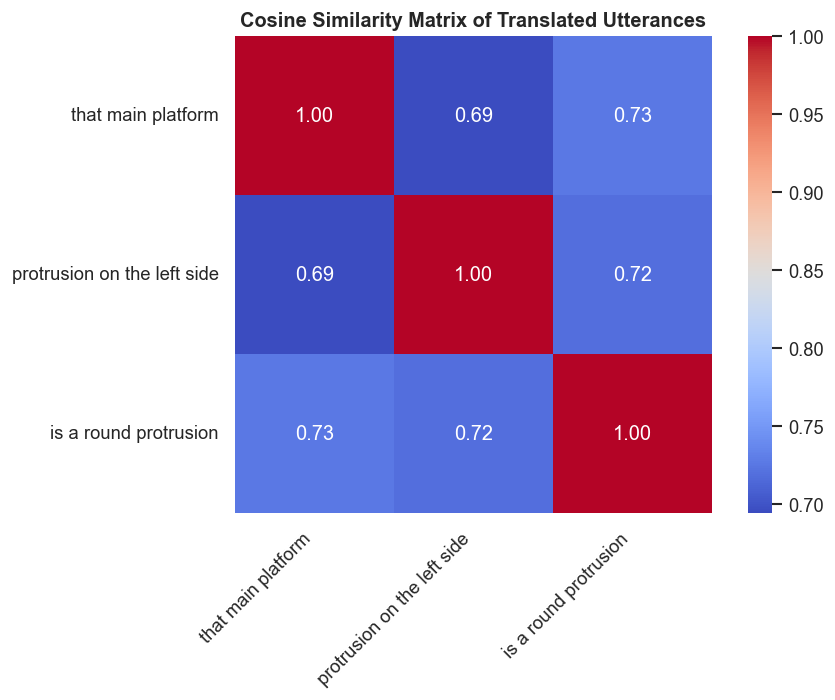

In [68]:
TEST = ['dat hoofdplatform', 'steeksel aan de linkerkant', 'is een rond uitsteeksel']
embs = encode_sentences(TEST, text_model, tokenizer)
print(embs.shape)  # (3, 768)

cos_sim = cosine_similarity(embs.cpu().numpy())
similarity_df = pd.DataFrame(cos_sim, index=TEST, columns=TEST)
display(similarity_df)

translated = ['that main platform', 'protrusion on the left side', 'is a round protrusion']
translated_similarity_df = pd.DataFrame(cos_sim, index=translated, columns=translated)

plt.figure(figsize=(8, 6))
sns.heatmap(translated_similarity_df, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)
plt.title('Cosine Similarity Matrix of Translated Utterances')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
def encode_utterances(utterances, mdl, tok, batch_size=64):
    """Mean-pooled Dutch-BERT vector for every utterance (batched for speed)."""
    utterances = ["" if pd.isna(u) else str(u).strip() for u in utterances]
    vectors = []
    for start in tqdm(range(0, len(utterances), batch_size), desc="BERT encoding"):
        batch = utterances[start:start + batch_size]
        vectors.append(encode_sentences(batch, mdl, tok).cpu().numpy())
    return list(np.vstack(vectors))

if REBUILD:
    gestures_df["semantic_embeddings"] = encode_utterances(gestures_df["lemmas"], text_model, tokenizer)
else:
    print("semantic_embeddings already in the cached table:", "semantic_embeddings" in gestures_df.columns)

print("Semantic embedding dim:", np.asarray(gestures_df["semantic_embeddings"].iat[0]).shape)

BERT encoding:   0%|          | 0/163 [00:00<?, ?it/s]

Semantic embedding dim: (768,)


## 3️⃣ Gesture embeddings 👐

We use the `Multimodal-X` encoder from **I see what you mean: Co-Speech Gestures for Reference Resolution
in Multimodal Dialogue** (Ghaleb et al., 2025). The model was trained contrastively on skeleton and
semantic features of *face-to-face* dialogue; here we apply it, unchanged, to the Zoom skeletons — a small
domain-transfer exercise in its own right.

**NOTE**: we first need to **automatically download** the model weights from Google Drive. The model is
available at [this link](https://drive.google.com/file/d/14lBbWLK53Ct6nOHV84yy2kXTeDh5I0TS/view?usp=sharing),
and is stored in the `pretrained_models/multimodal-x` folder.

In [16]:
# ——————— CONFIG TO DOWNLOAD THE MODEL ———————
DRIVE_FILE_ID = "14lBbWLK53Ct6nOHV84yy2kXTeDh5I0TS"
DEST_FOLDER   = pathlib.Path("pretrained_models/multimodal-x")
FILENAME      = "multimodal-x_skeleton_text.ckpt"
# ——————————————————————

def download_single_file(file_id: str, dest_folder: pathlib.Path, filename: str):
    """Download one Google-Drive file into dest_folder/filename if missing."""
    dest_folder.mkdir(parents=True, exist_ok=True)
    out_path = dest_folder / filename
    if out_path.exists():
        print(f"[✔] {out_path} already exists, skipping download.")
        return
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading to {out_path} …")
    gdown.download(url, str(out_path), quiet=False)
    print("[✔] Download complete.")

if REBUILD:
    download_single_file(DRIVE_FILE_ID, DEST_FOLDER, FILENAME)

def load_pretrained(params):
    path = params["model_weights"]
    params = params.copy(); _ = params.pop("model_weights")
    mdl = GSSModel(**params)
    w = torch.load(path, map_location="cpu")
    for k in mdl.state_dict():
        mdl.state_dict()[k].copy_(w["state_dict"]["model." + k])
    return mdl.to(DEVICE).eval()

[✔] pretrained_models/multimodal-x/multimodal-x_skeleton_text.ckpt already exists, skipping download.


In [17]:
MODELS = {
    "multimodal-x": {
        "modalities": ["skeleton", "semantic"],
        "hidden_dim": 256, "cross_modal": True, "attentive_pooling": False,
        "model_weights": "pretrained_models/multimodal-x/multimodal-x_skeleton_text.ckpt"},
}
GESTURE_KEY = "multimodal-x"

if REBUILD:
    gesture_model = load_pretrained(MODELS[GESTURE_KEY])
    gesture_model.eval()
    print(f"Model {GESTURE_KEY} pre-trained with modalities: {MODELS[GESTURE_KEY]['modalities']}")
else:
    gesture_model = None
    print("Skipping model loading - gesture embeddings come from the cache.")

Model multimodal-x pre-trained with modalities: ['skeleton', 'semantic']


### 🦴 From an annotated stroke to a model input

Three things differ from the face-to-face pipeline, and all of them live in the helper below:

1. **Frame rate** — the Zoom videos are 50 fps, so we take every second frame to reach the ~25 fps the
   encoder was trained on.
2. **One camera per participant** — each participant was filmed alone, so there is a single skeleton per
   gesture (no mirrored partner view to concatenate).
3. **Centring** — we subtract the temporal mean of the root joint so that the encoder sees the *movement*
   rather than where the person happened to sit in front of their camera.

Strokes longer than 60 frames are centre-cropped; strokes shorter than `MIN_CLIP_FRAMES` are padded by
repeating the last frame instead of being dropped.

In [18]:
def prepare_gesture_clip(keypoints, start_frame, end_frame,
                         frame_step=FRAME_STEP, max_frames=MAX_CLIP_FRAMES, min_frames=MIN_CLIP_FRAMES):
    """Cut a stroke out of a participant's pose array and shape it for the encoder.

    Returns an array of shape ``(1, C, T, V, 1)`` or ``None`` when the stroke is empty.
    """
    clip = np.asarray(keypoints)[start_frame:end_frame]          # (T, V, C)
    if clip.ndim == 4:                                            # (T, V, C, 1) -> (T, V, C)
        clip = clip.squeeze(-1)
    if clip.shape[0] == 0:
        return None

    clip = clip[::frame_step]                                     # 50 fps -> 25 fps
    if clip.shape[0] < min_frames:                                # pad very short strokes
        pad = np.repeat(clip[-1:], min_frames - clip.shape[0], axis=0)
        clip = np.concatenate([clip, pad], axis=0)
    if clip.shape[0] > max_frames:                                # keep the middle of long strokes
        offset = (clip.shape[0] - max_frames) // 2
        clip = clip[offset:offset + max_frames]

    x = clip.transpose(2, 0, 1)[..., None].astype(np.float32)     # (C, T, V, M=1)
    root = x[:2, :, 0, 0].mean(axis=1)                            # mean x/y of the root joint over time
    x[0] -= root[0]
    x[1] -= root[1]
    return x[None]                                                # (N=1, C, T, V, M)

def extract_gesture_embeddings(df, keypoints_dict, model, use_speech_modality=False):
    """Run the Multimodal-X encoder over every gesture stroke in `df`."""
    features = []
    for row in tqdm(df.itertuples(), total=len(df), desc="Gesture encoding"):
        keypoints = keypoints_dict.get(row.participant_id)
        clip = None if keypoints is None else prepare_gesture_clip(keypoints, row.start_frame, row.end_frame)
        if clip is None:
            features.append(None)
            continue

        tensor = torch.from_numpy(clip).float().to(DEVICE)
        tensor = tensor.squeeze(-1).permute(0, 2, 3, 1)            # (N, T, V, C) for the transformer backbone
        utterance = "" if pd.isna(row.lemmas) else str(row.lemmas).strip()

        try:
            with torch.no_grad():
                out = model(tensor,
                            speech_waveform=torch.zeros((1, 1, 1), device=DEVICE) if use_speech_modality else None,
                            utterances=[utterance])
            features.append(out["skeleton_features"].squeeze(0).cpu().numpy())
        except Exception as exc:
            print(f"[skip] {row.participant_id} @ {row.start_time:.2f}s: {exc}")
            features.append(None)
    return features

def keep_valid_embeddings(df, columns):
    """Drop rows whose embeddings are missing or have the wrong dimensionality."""
    out = df.reset_index(drop=True).copy()
    ok = np.ones(len(out), dtype=bool)
    for col in columns:
        dims = out[col].map(lambda v: 0 if v is None else np.asarray(v).reshape(-1).size)
        if (dims > 0).sum() == 0:
            raise ValueError(f"Column '{col}' contains no usable embeddings.")
        modal_dim = int(dims[dims > 0].mode().iat[0])
        ok &= (dims == modal_dim).to_numpy()
        out[col] = out[col].map(lambda v: None if v is None else np.asarray(v, dtype=np.float32).reshape(-1))
    dropped = int((~ok).sum())
    if dropped:
        print(f"Dropped {dropped} gesture(s) with missing/short skeleton data.")
    return out[ok].reset_index(drop=True)

In [19]:
EMBEDDING_PREFERENCE = ["multimodal-x"]#, "crossmodal-semantic-best", "crossmodal-semantic", "crossmodal-semantic-old", "unimodal_skeleton", "gcn_features"]

if REBUILD:
    gestures_df[GESTURE_KEY] = extract_gesture_embeddings(gestures_df, keypoints_dict, gesture_model)
    gestures_df = keep_valid_embeddings(gestures_df, [GESTURE_KEY, "semantic_embeddings"])
    gestures_df.to_pickle(CACHE_PKL)
    print(f"[✔] Cached the processed table to {CACHE_PKL}")
else:
    available = [c for c in EMBEDDING_PREFERENCE if c in gestures_df.columns]
    if not available:
        raise KeyError(f"No gesture-embedding column found in the cache. Columns: {list(gestures_df.columns)}")
    GESTURE_KEY = available[0]
    print("Gesture-embedding columns in the cache:", available)
    gestures_df = keep_valid_embeddings(gestures_df, [GESTURE_KEY, "semantic_embeddings"])

print(f"Using '{GESTURE_KEY}' | embedding dim: {np.asarray(gestures_df[GESTURE_KEY].iat[0]).size} "
      f"| gestures: {len(gestures_df):,}")

Gesture encoding:   0%|          | 0/10374 [00:00<?, ?it/s]

/opt/anaconda3/envs/test2/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Dropped 1 gesture(s) with missing/short skeleton data.
[✔] Cached the processed table to data/technology_mediated_interaction/processed_gestures_iconicity_with_semantic_and_gesture_all_embeddings.pkl
Using 'multimodal-x' | embedding dim: 128 | gestures: 10,373


## 4️⃣ Similarity analysis 🔍 Intrinsic Gesture-Similarity Evaluation

Following Section 5 of the ICMI paper, we compare cosine similarity scores across logically defined
*pair types*:

| Pair Type | Same Speaker | Same Referent | Same Dialogue |
|-----------|--------------|---------------|---------------|
| **same-ref & same-speaker** | ✅ | ✅ | ✅ |
| **same-ref & diff-speaker** | ❌ | ✅ | ✅ |
| **diff-ref & same-speaker** | ✅ | ❌ | ✅ |
| **diff-ref & diff-speaker** | ❌ | ❌ | ✅ |
| **Cross-Dialogue & same-ref** | ❌ | ✅ | ❌ |
| **Cross-Dialogue & diff-ref** | ❌ | ❌ | ❌ |

**One change for this corpus:** every pair is formed *within a visibility condition*. Comparing a Sym
gesture with an AO gesture would confound "who could see whom" with everything else, so the condition is
kept as a label on the pair and the Sym/AO contrast gets its own section (§9️⃣).

**NOTE**: the similarity analysis uses the `gesture` embeddings, the `semantic` embeddings, or their
concatenation (`multimodal`) — set with the `modality` argument below.

Because the number of pairs grows quadratically (all ~7.5k iconic gestures would give ~28M pairs), the
notebook works on a random subsample of gestures (`MAX_GESTURES`) and caps the number of rows per pair
type (`MAX_PAIRS_PER_TYPE`). Both are set in the configuration cell; set them to `None` for the full data.

In [71]:
PAIR_TYPES = [
    "Same P&R&S",          # same dialogue, same speaker,      same referent
    "Same P&S - Diff R",   # same dialogue, same speaker,      different referent
    "Same R &P - diff S",  # same dialogue, different speaker, same referent
    "Same P - Diff R&S",   # same dialogue, different speaker, different referent
    "Same R - Diff P&S",   # different dialogue, different speaker, same referent
    "Diff P&R&S",          # different dialogue, different speaker, different referent
]

PAIR_LABELS = {
    "Same P&R&S":         "same-ref\nsame-speaker",
    "Same P&S - Diff R":  "diff-ref\nsame-speaker",
    "Same R &P - diff S": "same-ref\ndiff-speaker",
    "Same P - Diff R&S":  "diff-ref\ndiff-speaker",
    "Same R - Diff P&S":  "same-ref\ndiff-dialogue",
    "Diff P&R&S":         "diff-ref\ndiff-dialogue",
}

def sample_gestures(df, max_gestures=MAX_GESTURES, conditions=CONDITIONS, random_state=RANDOM_STATE):
    """Keep the conditions we analyse and (optionally) subsample, preserving the condition balance."""
    out = df[df["Condition"].isin(conditions)].reset_index(drop=True)
    if max_gestures is not None and len(out) > max_gestures:
        frac = max_gestures / len(out)
        out = (out.groupby("Condition", observed=True)
                  .sample(frac=frac, random_state=random_state)
                  .sort_index())
    return out.reset_index(drop=True)

analysis_df = sample_gestures(gestures_df)
print(f"Gestures entering the pairwise analysis: {len(analysis_df):,}")
display(analysis_df["Condition"].value_counts().rename("gestures").to_frame())

Gestures entering the pairwise analysis: 6,249


,gestures
Condition,
Sym,3540
AO,2709


In [72]:
def stack_feature_column(series: pd.Series, column_name: str) -> np.ndarray:
    """Stack a column of embedding arrays into a 2-D matrix, checking dimensions."""
    arrays, target_dim = [], None
    for value in series:
        arr = np.empty(0, dtype=np.float32) if value is None else np.asarray(value, dtype=np.float32).reshape(-1)
        if arr.size > 0:
            if target_dim is None:
                target_dim = arr.size
            elif arr.size != target_dim:
                raise ValueError(f"Inconsistent embedding length in '{column_name}': "
                                 f"expected {target_dim}, got {arr.size}.")
        arrays.append(arr)
    if target_dim is None:
        raise ValueError(f"No non-empty embeddings found in column '{column_name}'.")
    return np.vstack([a if a.size else np.zeros(target_dim, dtype=np.float32) for a in arrays])


def compute_cosine_similarity(df: pd.DataFrame, model_key: str, modality: str) -> np.ndarray:
    """Cosine-similarity matrix over gesture, semantic, or concatenated multimodal features."""
    if modality == "gesture":
        feats = stack_feature_column(df[model_key], model_key)
    elif modality == "semantic":
        feats = stack_feature_column(df["semantic_embeddings"], "semantic_embeddings")
    elif modality == "multimodal":
        vis = stack_feature_column(df[model_key], model_key)
        sem = stack_feature_column(df["semantic_embeddings"], "semantic_embeddings")
        feats = np.concatenate([vis, sem], axis=1)
    else:
        raise ValueError("modality must be gesture|semantic|multimodal")
    return cosine_similarity(feats)


def create_pairs_df_for_comparisons(df: pd.DataFrame, sim_mat: np.ndarray,
                                    within_condition: bool = True,
                                    max_pairs_per_type: int = MAX_PAIRS_PER_TYPE,
                                    random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Build a table of pairwise similarities labelled with the ICMI pair types.

    The pair labelling is vectorised (numpy) rather than looped, so the full upper triangle of a few
    thousand gestures is built in seconds. `within_condition=True` only keeps pairs of gestures that
    come from the same visibility condition.
    """
    n = len(df)
    i_idx, j_idx = np.triu_indices(n, k=1)

    speaker   = df["pair_speaker"].to_numpy()
    referent  = df["referent_clean"].to_numpy()
    dialogue  = df["Pair"].to_numpy()
    condition = df["Condition"].to_numpy()
    rounds    = df["round_num"].to_numpy()

    if within_condition:
        keep = condition[i_idx] == condition[j_idx]
        i_idx, j_idx = i_idx[keep], j_idx[keep]

    same_speaker  = speaker[i_idx] == speaker[j_idx]
    same_referent = referent[i_idx] == referent[j_idx]
    same_dialogue = dialogue[i_idx] == dialogue[j_idx]

    codes = np.full(len(i_idx), -1, dtype=np.int8)
    codes[same_dialogue & same_speaker & same_referent]        = 0   # Same P&R&S
    codes[same_dialogue & same_speaker & ~same_referent]       = 1   # Same P&S - Diff R
    codes[same_dialogue & ~same_speaker & same_referent]       = 2   # Same R &P - diff S
    codes[same_dialogue & ~same_speaker & ~same_referent]      = 3   # Same P - Diff R&S
    codes[~same_dialogue & ~same_speaker & same_referent]      = 4   # Same R - Diff P&S
    codes[~same_dialogue & ~same_speaker & ~same_referent]     = 5   # Diff P&R&S

    valid = codes >= 0
    i_idx, j_idx, codes = i_idx[valid], j_idx[valid], codes[valid]

    if max_pairs_per_type is not None:
        rng = np.random.default_rng(random_state)
        selected = []
        for c in range(len(PAIR_TYPES)):
            idx = np.flatnonzero(codes == c)
            if len(idx) > max_pairs_per_type:
                idx = rng.choice(idx, size=max_pairs_per_type, replace=False)
            selected.append(idx)
        order = np.sort(np.concatenate(selected)) if selected else np.array([], dtype=int)
        i_idx, j_idx, codes = i_idx[order], j_idx[order], codes[order]

    return pd.DataFrame({
        "index_i":    i_idx,
        "index_j":    j_idx,
        "similarity": sim_mat[i_idx, j_idx],
        "pair_type":  pd.Categorical.from_codes(codes, PAIR_TYPES),
        "condition":  condition[i_idx],
        "speaker_i":  speaker[i_idx],  "speaker_j":  speaker[j_idx],
        "dialogue_i": dialogue[i_idx], "dialogue_j": dialogue[j_idx],
        "referent_i": referent[i_idx], "referent_j": referent[j_idx],
        "round_i":    rounds[i_idx],   "round_j":    rounds[j_idx],
    })


def pair_scores(sim_mat: np.ndarray, pairs) -> np.ndarray:
    """Return an array of similarity scores for the given index pairs."""
    return np.array([sim_mat[i, j] for i, j in pairs])

In [73]:
MODALITY = "gesture"   # 'gesture' | 'semantic' | 'multimodal'

sim_matrix = compute_cosine_similarity(analysis_df, GESTURE_KEY, modality=MODALITY)
similarities_df = create_pairs_df_for_comparisons(analysis_df, sim_matrix)

print(f"{len(similarities_df):,} labelled gesture pairs")
display(pd.crosstab(similarities_df["pair_type"], similarities_df["condition"]))

9,932,016 labelled gesture pairs


condition,AO,Sym
pair_type,,
Same P&R&S,5232,7260
Same P&S - Diff R,207946,269312
Same R &P - diff S,2588,5492
Same P - Diff R&S,123399,252085
Same R - Diff P&S,60214,107532
Diff P&R&S,3268607,5622349


### 🎨 Plotting helpers

The three figures below follow the face-to-face tutorial (box / violin / bar plots with significance
brackets). The only addition is the `condition` argument, which restricts a figure to one visibility
condition — by default `REFERENCE_CONDITION` (`Sym`), the closest analogue to face-to-face dialogue.

In [74]:
def p_to_stars(p):
    if pd.isna(p):
        return "n.a."
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."


def select_pairs(similarities_df, order, condition=None, subsample=False, random_state=RANDOM_STATE):
    """Keep the requested pair types (and condition) and optionally balance the group sizes."""
    df = similarities_df[similarities_df["pair_type"].isin(order)].copy()
    if condition is not None:
        df = df[df["condition"] == condition]
    if df.empty:
        raise ValueError(f"No pairs left for condition={condition!r} and pair types {order}.")
    if subsample:
        counts = df["pair_type"].value_counts().reindex(order).dropna()
        n_min = int(counts.min())
        df = df.groupby("pair_type", observed=True).sample(n=n_min, random_state=random_state)
    df["pair_type"] = pd.Categorical(df["pair_type"].astype(str), categories=order, ordered=True)
    return df.reset_index(drop=True)


def annotate_comparisons(ax, df, order, comparisons, x="pair_type", y="similarity"):
    """Add significance brackets, via statannotations when available, otherwise manually."""
    if HAS_STATANNOT:
        annotator = Annotator(ax, comparisons, data=df, x=x, y=y, order=order)
        annotator.configure(test="t-test_ind", text_format="star", loc="inside",
                            comparisons_correction="Bonferroni", hide_non_significant=True)
        annotator.apply_and_annotate()
        return

    positions = {key: i for i, key in enumerate(order)}
    values = df[y].to_numpy(dtype=float)
    span = float(np.nanmax(values) - np.nanmin(values)) or 1.0
    level, top = 0, float(np.nanmax(values))
    for a, b in comparisons:
        va = df.loc[df[x] == a, y].to_numpy(dtype=float)
        vb = df.loc[df[x] == b, y].to_numpy(dtype=float)
        if len(va) < 2 or len(vb) < 2:
            continue
        _, p = ttest_ind(va, vb, equal_var=False)
        p = min(1.0, p * len(comparisons))            # Bonferroni
        stars = p_to_stars(p)
        if stars == "n.s.":
            continue
        y_line = top + span * (0.06 + 0.08 * level)
        xa, xb = positions[a], positions[b]
        ax.plot([xa, xa, xb, xb],
                [y_line, y_line + span * 0.02, y_line + span * 0.02, y_line],
                lw=1.3, c="0.25")
        ax.text((xa + xb) / 2, y_line + span * 0.025, stars, ha="center", va="bottom", fontsize=12)
        level += 1
    ax.set_ylim(top=top + span * (0.10 + 0.08 * max(level, 1)))

## 5️⃣ Speaker-Level Analysis: Speaker & Referent Effects

Following the ICMI paper (§5.2.1, hypothesis **H1a**), we compare positive vs negative gesture pairs
(same vs different referent) **within a speaker**:

| Pair Type | Same Speaker | Same Referent | Same Dialogue |
|-----------|--------------|---------------|---------------|
| **same-ref & same-speaker** | ✅ | ✅ | ✅ |
| **diff-ref & same-speaker** | ✅ | ❌ | ✅ |

Essentially, we compare gestures (and the semantic representations of their co-occurring speech) that
refer to the same object and are produced by the same speaker, against gestures that refer to different
objects but are produced by the same speaker.

In [75]:
similarities_df.head()

,index_i,index_j,similarity,pair_type,condition,speaker_i,speaker_j,dialogue_i,dialogue_j,referent_i,referent_j,round_i,round_j
0,0,1,0.754486,Same P&R&S,Sym,001_a,001_a,1,1,B09,B09,1.0,1.0
1,0,2,0.724760,Same P&R&S,Sym,001_a,001_a,1,1,B09,B09,1.0,1.0
2,0,3,0.417286,Same P&S - Diff R,Sym,001_a,001_a,1,1,B09,A09,1.0,1.0
3,0,4,0.791764,Same P&S - Diff R,Sym,001_a,001_a,1,1,B09,D09,1.0,1.0
4,0,5,0.363136,Same P&S - Diff R,Sym,001_a,001_a,1,1,B09,D09,1.0,1.0


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same P&R&S vs. Same P&S - Diff R: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=6.480e+01


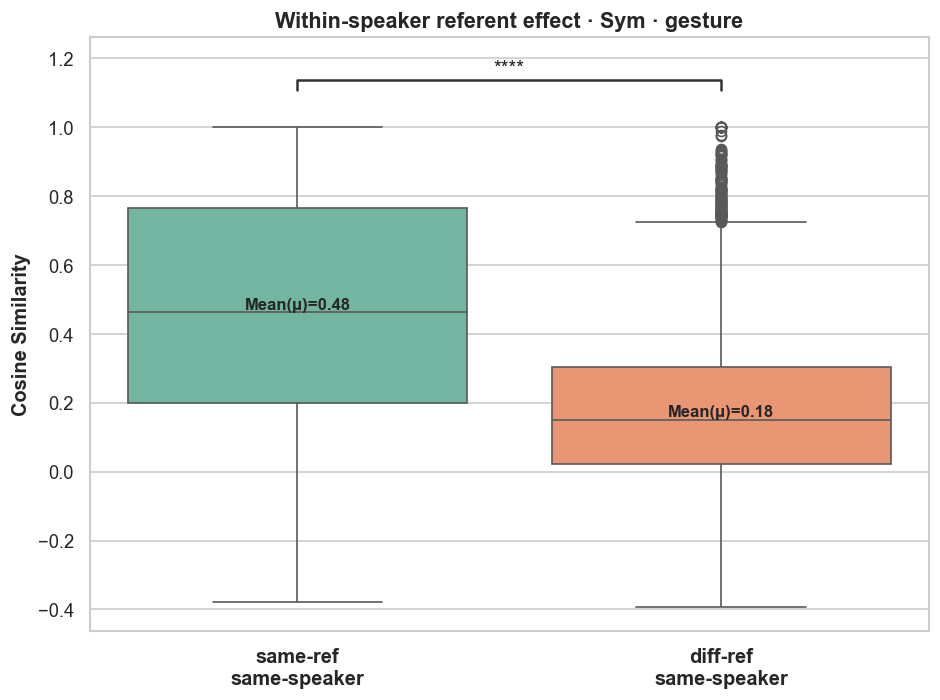

In [76]:
def plot_same_speaker_similarity(similarities_df, subsample=True, condition=REFERENCE_CONDITION):
    """Box plot of same-speaker similarity for same vs different referents."""
    order = ["Same P&R&S", "Same P&S - Diff R"]
    df = select_pairs(similarities_df, order, condition=condition, subsample=subsample)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    palette = sns.color_palette("Set2", n_colors=len(order))
    sns.boxplot(x="pair_type", y="similarity", data=df, order=order, palette=palette, ax=ax)

    annotate_comparisons(ax, df, order, [("Same P&R&S", "Same P&S - Diff R")])

    for i, key in enumerate(order):
        subset = df[df["pair_type"] == key]["similarity"]
        ax.text(i, subset.median(), f"Mean(μ)={subset.mean():.2f}",
                ha="center", va="bottom", fontsize=10, weight="bold")

    ax.set_xlabel("")
    ax.set_ylabel("Cosine Similarity", fontweight="bold", fontsize=12)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([PAIR_LABELS[k] for k in order], fontweight="bold", fontsize=12)
    ax.set_title(f"Within-speaker referent effect · {condition or 'all conditions'} · {MODALITY}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_same_speaker_similarity(similarities_df, subsample=True)

## 6️⃣ Dialogue-level analysis

Replicating the **speaker ✕ referent** effects reported in §5.2.1 of the ICMI paper (**H1b** and **H2**).

| Pair Type | Same Speaker | Same Referent | Same Dialogue |
|-----------|--------------|---------------|---------------|
| **same-ref & same-speaker** | ✅ | ✅ | ✅ |
| **diff-ref & same-speaker** | ✅ | ❌ | ✅ |
| **same-ref & diff-speaker** | ❌ | ✅ | ✅ |
| **diff-ref & diff-speaker** | ❌ | ❌ | ✅ |

The comparison has two parts:

1. **Same speaker**: gestures that refer to the same object and are produced by the same speaker.
2. **Cross speaker**: gestures that refer to the same object but are produced by different speakers in the
   **same dialogue** — i.e. the interlocutors of one Zoom call.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same P&R&S vs. Same P&S - Diff R: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=5.680e+01
Same R &P - diff S vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:1.269e-132 t=2.490e+01
Same P&S - Diff R vs. Same R &P - diff S: t-test independent samples with Bonferroni correction, P_val:1.265e-18 t=-8.979e+00
Same P&S - Diff R vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:5.540e-50 t=1.503e+01


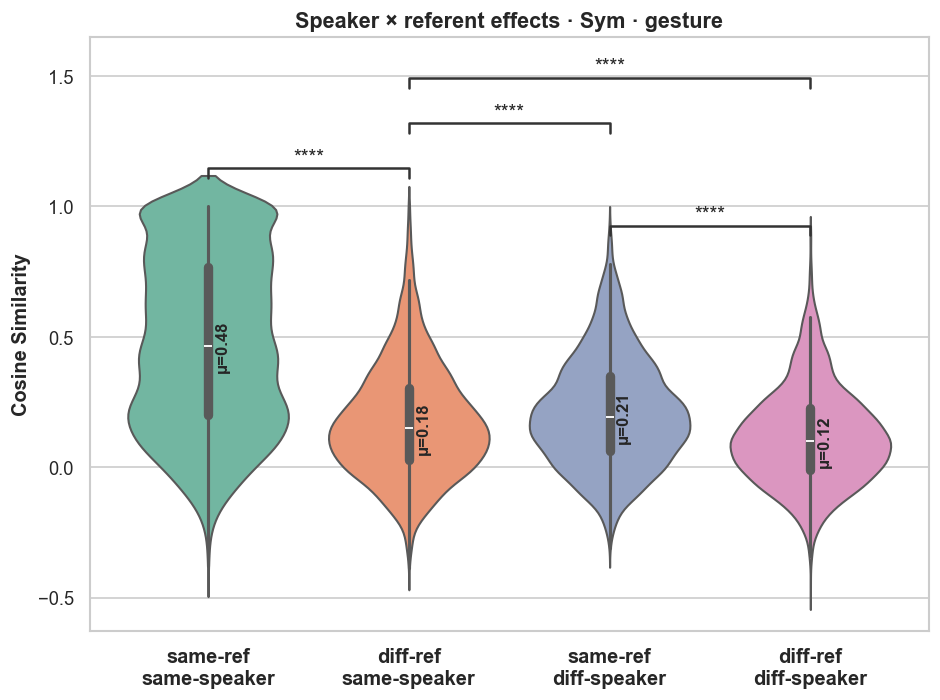

In [77]:
def plot_cross_speaker_similarity(similarities_df, subsample=True, condition=REFERENCE_CONDITION):
    """Violin plot across the four within-dialogue pair types."""
    order = ["Same P&R&S", "Same P&S - Diff R", "Same R &P - diff S", "Same P - Diff R&S"]
    df = select_pairs(similarities_df, order, condition=condition, subsample=subsample)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    palette = sns.color_palette("Set2", n_colors=len(order))
    sns.violinplot(x="pair_type", y="similarity", data=df, order=order, palette=palette, ax=ax)

    annotate_comparisons(ax, df, order, [
        ("Same P&R&S", "Same P&S - Diff R"),
        ("Same R &P - diff S", "Same P - Diff R&S"),
        ("Same P&S - Diff R", "Same R &P - diff S"),
        ("Same P&S - Diff R", "Same P - Diff R&S"),
    ])

    for i, key in enumerate(order):
        subset = df[df["pair_type"] == key]["similarity"]
        ax.text(i + 0.07, subset.median() - 0.1, f"μ={subset.mean():.2f}",
                ha="center", va="bottom", fontsize=10, weight="bold", rotation=90)

    ax.set_xlabel("")
    ax.set_ylabel("Cosine Similarity", fontweight="bold", fontsize=12)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([PAIR_LABELS[k] for k in order], fontweight="bold", fontsize=12)
    ax.set_title(f"Speaker × referent effects · {condition or 'all conditions'} · {MODALITY}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_cross_speaker_similarity(similarities_df, subsample=True)

## 7️⃣ Cross-dialogue analysis

Replicating the **Referent vs. Interaction Driven Similarity** analysis (§5.2.2, hypothesis **H3**): are
two gestures for the same Fribble subpart more similar when their producers were *talking to each other*
than when they were in different Zoom calls?

| Pair Type | Same Speaker | Same Referent | Same Dialogue |
|-----------|--------------|---------------|---------------|
| **same-ref & diff-speaker** | ❌ | ✅ | ✅ |
| **diff-ref & diff-speaker** | ❌ | ❌ | ✅ |
| **Cross-Dialogue & same-ref** | ❌ | ✅ | ❌ |
| **Cross-Dialogue & diff-ref** | ❌ | ❌ | ❌ |

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same R &P - diff S vs. Same R - Diff P&S: t-test independent samples with Bonferroni correction, P_val:4.381e-88 t=1.997e+01
Same P - Diff R&S vs. Diff P&R&S: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=5.338e+01
Same R - Diff P&S vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=4.566e+01


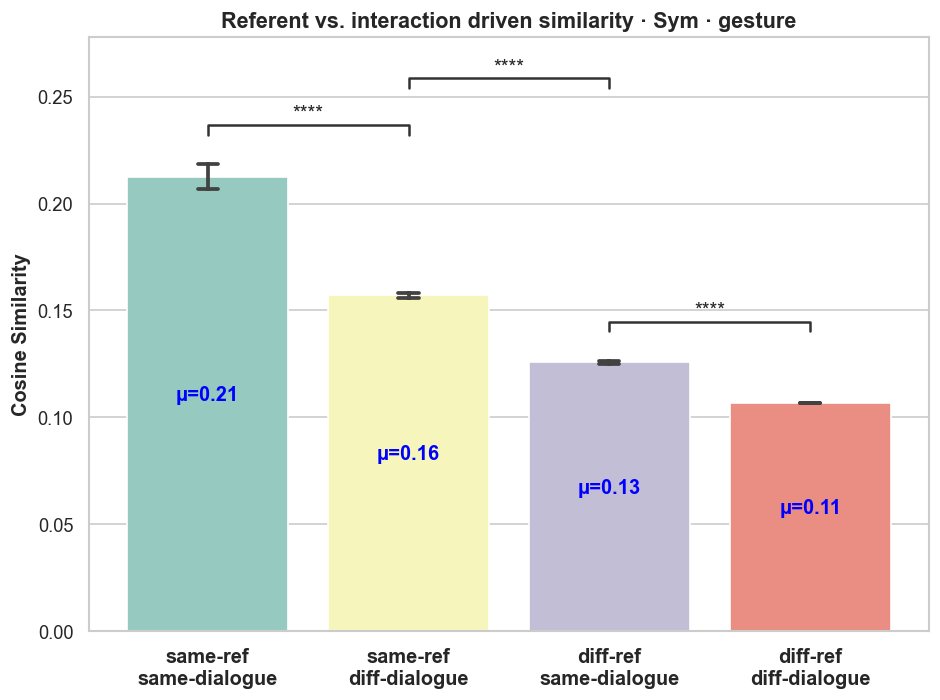

In [78]:
def plot_cross_dialogue_similarity(similarities_df, subsample=False, condition=REFERENCE_CONDITION):
    """Bar plot contrasting within-dialogue and cross-dialogue similarity."""
    order = ["Same R &P - diff S", "Same R - Diff P&S", "Same P - Diff R&S", "Diff P&R&S"]
    labels = {
        "Same R &P - diff S": "same-ref\nsame-dialogue",
        "Same R - Diff P&S":  "same-ref\ndiff-dialogue",
        "Same P - Diff R&S":  "diff-ref\nsame-dialogue",
        "Diff P&R&S":         "diff-ref\ndiff-dialogue",
    }
    df = select_pairs(similarities_df, order, condition=condition, subsample=subsample)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    palette = sns.color_palette("Set3", n_colors=len(order))
    sns.barplot(x="pair_type", y="similarity", data=df, order=order, palette=palette,
                capsize=0.1, ax=ax, **BAR_ERR_KW)

    annotate_comparisons(ax, df, order, [
        ("Same R &P - diff S", "Same R - Diff P&S"),
        ("Same P - Diff R&S", "Diff P&R&S"),
        ("Same R - Diff P&S", "Same P - Diff R&S"),
    ])

    for i, key in enumerate(order):
        mean_val = df[df["pair_type"] == key]["similarity"].mean()
        ax.text(i, mean_val / 2, f"μ={mean_val:.2f}",
                ha="center", va="bottom", fontsize=12, weight="bold", color="blue")

    ax.set_xlabel("")
    ax.set_ylabel("Cosine Similarity", fontweight="bold", fontsize=12)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([labels[k] for k in order], fontweight="bold", fontsize=12)
    ax.set_title(f"Referent vs. interaction driven similarity · {condition or 'all conditions'} · {MODALITY}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_cross_dialogue_similarity(similarities_df, subsample=False)

## 8️⃣ Distribution view: KDE plots

Bar plots and box plots compress each pair type into a couple of numbers. Because the similarity
distributions are wide and skewed, it is worth looking at them in full: the KDE figures below show the
same H1/H2/H3 contrasts as densities, with the medians marked and a Welch t-test in the corner.

In [79]:
BINARY_COLOR_ORDER = ["#D2B047", "#164A5E"]   # gold, dark teal


def _welch_test_text(a, b):
    """Compact Welch-test label for two distributions."""
    if len(a) < 2 or len(b) < 2:
        return "Welch t-test: not enough samples"
    t_stat, p_val = ttest_ind(a, b, equal_var=False, nan_policy="omit")
    if p_val < 1e-4:
        return f"Welch t={t_stat:.2f}, p<0.0001 ({p_to_stars(p_val)})"
    return f"Welch t={t_stat:.2f}, p={p_val:.4f} ({p_to_stars(p_val)})"


def plot_binary_hypothesis_kde(similarities_df, pair_to_group, order, legend_labels, title,
                               condition=REFERENCE_CONDITION, subsample=True, bw_adjust=0.9,
                               rug=True, random_state=RANDOM_STATE, figsize=(8.5, 5.6), save_path=None):
    """KDE of the similarity distributions for a two-group (binary) contrast."""
    df = similarities_df[similarities_df["pair_type"].isin(pair_to_group)].copy()
    if condition is not None:
        df = df[df["condition"] == condition]
    df["group"] = df["pair_type"].astype(str).map(pair_to_group)
    df["similarity"] = pd.to_numeric(df["similarity"], errors="coerce")
    df = df.dropna(subset=["similarity", "group"])

    valid = [g for g in order
             if df.loc[df["group"] == g, "similarity"].nunique() > 1
             and df.loc[df["group"] == g, "similarity"].notna().sum() >= 2]
    if not valid:
        raise ValueError("KDE needs at least one group with two or more distinct similarity values.")

    if subsample and len(valid) >= 2:
        n_min = int(df[df["group"].isin(valid)].groupby("group", observed=True).size().min())
        df = df[df["group"].isin(valid)].groupby("group", observed=True).sample(n=n_min, random_state=random_state)

    palette = {g: BINARY_COLOR_ORDER[i % len(BINARY_COLOR_ORDER)] for i, g in enumerate(order) if g in valid}
    labels = dict(zip(order, legend_labels))

    sns.set_theme(context="talk", style="whitegrid",
                  rc={"axes.spines.right": False, "axes.spines.top": False,
                      "axes.titleweight": "bold", "figure.dpi": 120})
    fig, ax = plt.subplots(figsize=figsize)

    plot_df = df[df["group"].isin(valid)]
    sns.kdeplot(data=plot_df, x="similarity", hue="group", hue_order=valid, palette=palette,
                fill=True, alpha=0.24, linewidth=2.4, bw_adjust=bw_adjust,
                cut=0, clip=(-1, 1), common_norm=False, ax=ax)

    if rug:
        rug_df = plot_df.groupby("group", observed=True).sample(
            n=min(700, int(plot_df.groupby("group", observed=True).size().min())), random_state=random_state)
        sns.rugplot(data=rug_df, x="similarity", hue="group", hue_order=valid, palette=palette,
                    alpha=0.14, height=0.035, legend=False, ax=ax)

    summary_lines = []
    for group in valid:
        vals = df.loc[df["group"] == group, "similarity"].dropna().to_numpy(dtype=float)
        median_val, mean_val = float(np.median(vals)), float(np.mean(vals))
        q25, q75 = np.quantile(vals, [0.25, 0.75])
        ax.axvline(median_val, color=palette[group], linestyle="--", linewidth=1.9, alpha=0.95)
        summary_lines.append(f"{labels.get(group, group)}: n={len(vals):,}, median={median_val:.3f}, "
                             f"mean={mean_val:.3f}, IQR={q25:.3f}–{q75:.3f}")

    if len(valid) == 2:
        a = df.loc[df["group"] == valid[0], "similarity"].to_numpy(dtype=float)
        b = df.loc[df["group"] == valid[1], "similarity"].to_numpy(dtype=float)
        summary_lines.append(_welch_test_text(a, b))

    x_low, x_high = np.quantile(plot_df["similarity"].to_numpy(dtype=float), [0.005, 0.995])
    pad = max((x_high - x_low) * 0.07, 0.02)
    ax.set_xlim(max(-1, x_low - pad), min(1, x_high + pad))

    ax.set_title(f"{title} · {condition or 'all conditions'}", loc="left", fontsize=15, pad=12)
    ax.set_xlabel("Cosine similarity", fontsize=13, fontweight="bold")
    ax.set_ylabel("Density", fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.25); ax.grid(axis="x", alpha=0.10)

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("")
        for text in legend.texts:
            text.set_text(labels.get(text.get_text(), text.get_text()))

    ax.text(0.99, -0.22, "\n".join(summary_lines), transform=ax.transAxes, ha="right", va="top",
            fontsize=9.5, bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                                    edgecolor="0.85", alpha=0.92))
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", transparent=True)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


def plot_h1_same_vs_diff_referent_kde(similarities_df, condition=REFERENCE_CONDITION, subsample=True, save_path=None):
    """H1: same-referent vs different-referent pairs."""
    return plot_binary_hypothesis_kde(
        similarities_df,
        pair_to_group={"Same P&R&S": "Same referent", "Same R &P - diff S": "Same referent",
                       "Same R - Diff P&S": "Same referent", "Same P&S - Diff R": "Different referent",
                       "Same P - Diff R&S": "Different referent", "Diff P&R&S": "Different referent"},
        order=["Same referent", "Different referent"],
        legend_labels=["Same referent", "Different referent"],
        title="H1: similarity by referent match",
        condition=condition, subsample=subsample, save_path=save_path)


def plot_h2_same_vs_diff_speaker_kde(similarities_df, condition=REFERENCE_CONDITION, subsample=True, save_path=None):
    """H2: same-referent gestures by the same vs a different speaker."""
    return plot_binary_hypothesis_kde(
        similarities_df,
        pair_to_group={"Same P&R&S": "Same speaker", "Same R &P - diff S": "Different speaker",
                       "Same R - Diff P&S": "Different speaker"},
        order=["Same speaker", "Different speaker"],
        legend_labels=["Same speaker", "Different speaker"],
        title="H2: similarity by speaker match (same referent)",
        condition=condition, subsample=subsample, save_path=save_path)


def plot_h3_same_ref_same_vs_diff_dialogue_kde(similarities_df, condition=REFERENCE_CONDITION, subsample=True, save_path=None):
    """H3: same-referent gestures by interlocutors vs by strangers."""
    return plot_binary_hypothesis_kde(
        similarities_df,
        pair_to_group={"Same R &P - diff S": "Same dialogue", "Same R - Diff P&S": "Different dialogue"},
        order=["Same dialogue", "Different dialogue"],
        legend_labels=["Same dialogue", "Different dialogue"],
        title="H3: same-referent similarity by dialogue match",
        condition=condition, subsample=subsample, save_path=save_path)

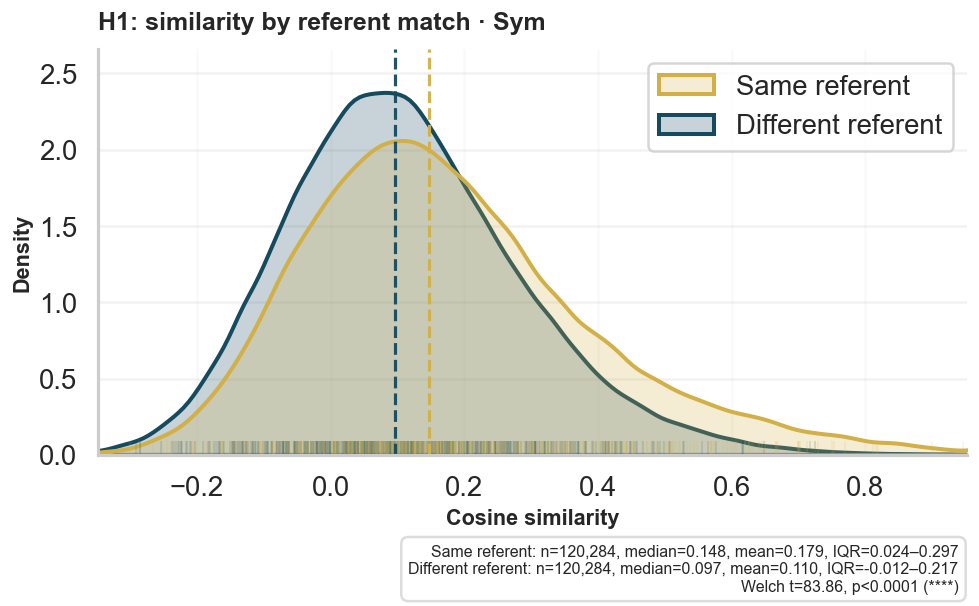

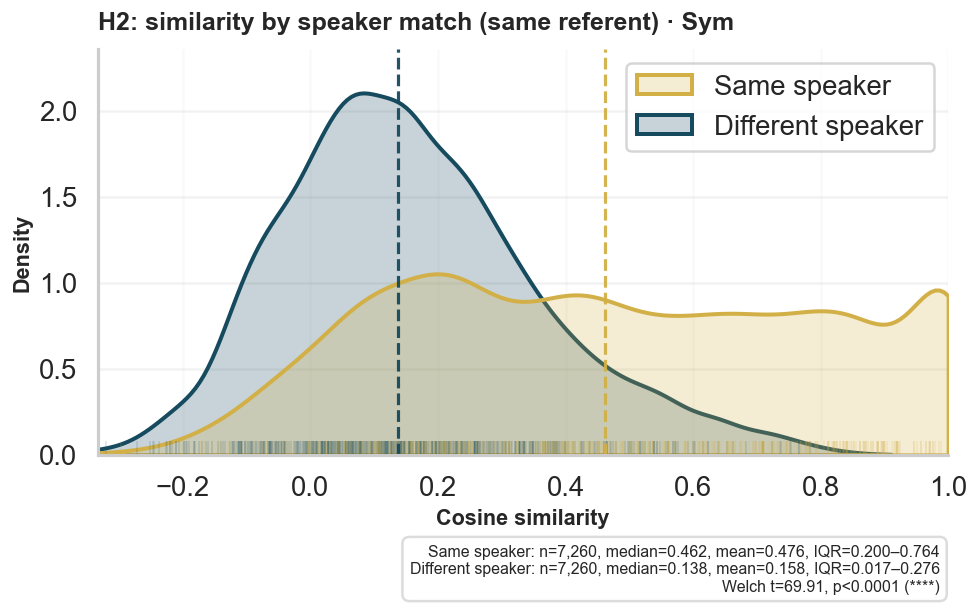

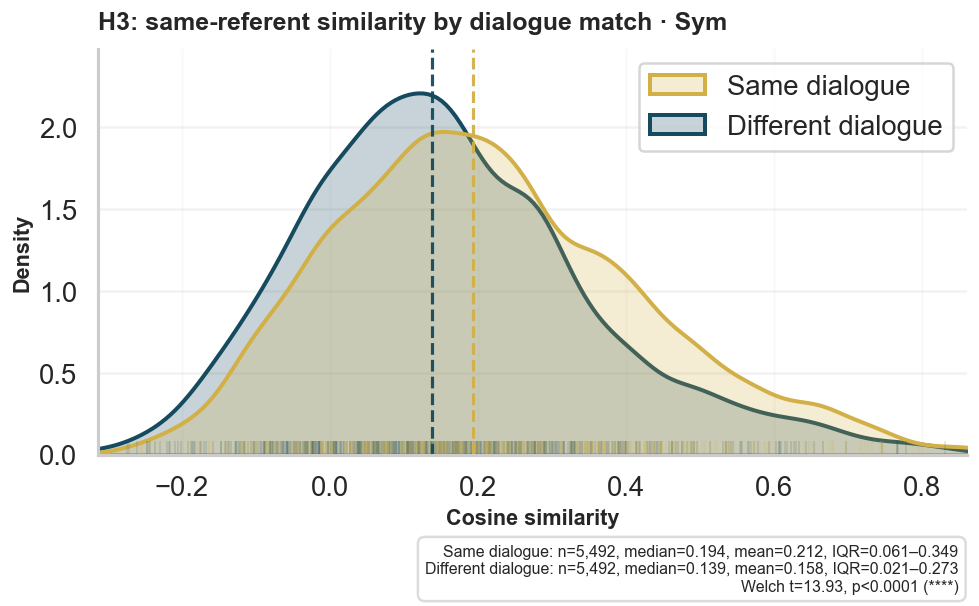

In [80]:
plot_h1_same_vs_diff_referent_kde(similarities_df, subsample=True)
plot_h2_same_vs_diff_speaker_kde(similarities_df, subsample=True)
plot_h3_same_ref_same_vs_diff_dialogue_kde(similarities_df, subsample=True)

## 9️⃣ Visibility conditions 🎥🎧 — does seeing your partner matter?

Everything so far described one condition at a time. The Zoom corpus lets us ask a question the
face-to-face data cannot answer: **how much of the cross-speaker similarity survives when the partners
cannot see each other's gestures?**

* In **Sym** both cameras are on: partners can be *primed* by each other's gestures and can *ground* their
  descriptions multimodally.
* In **AO** both cameras are off: any remaining similarity between two interlocutors must come from the
  shared referent, the shared task, and their converging *words* — not from seeing each other.

Two contrasts are informative:

| Pair type | What it measures | Prediction |
|-----------|------------------|------------|
| `same-ref & diff-speaker` (same dialogue) | cross-speaker alignment | higher in **Sym** than in **AO** |
| `same-ref & same-speaker` | a speaker's own consistency | should be similar in both conditions |

The second acts as a control: it should be largely unaffected by whether the partner's camera was on.

Balanced to 2,588 pairs per pair type × condition cell.


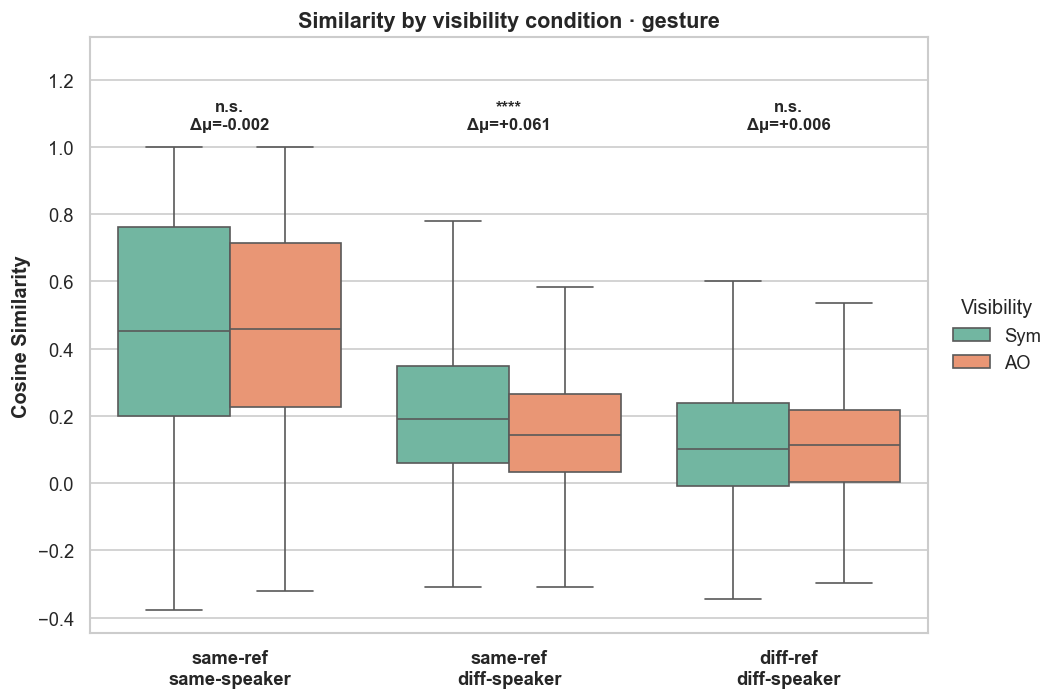

,n_Sym,mean_Sym,n_AO,mean_AO,diff,welch_t,p,sig
pair_type,,,,,,,,
Same P&R&S,2588,0.4748,2588,0.4764,-0.0016,-0.1805,0.8568,n.s.
Same R &P - diff S,2588,0.2114,2588,0.1505,0.0609,11.5295,0.0000,****
Same P - Diff R&S,2588,0.1236,2588,0.1180,0.0056,1.1630,0.2449,n.s.


In [81]:
def condition_stats(similarities_df, pair_types=None, conditions=CONDITIONS):
    """Mean similarity per pair type × condition, with a Welch test between the two conditions."""
    pair_types = pair_types or PAIR_TYPES
    rows = []
    for pair_type in pair_types:
        subset = similarities_df[similarities_df["pair_type"] == pair_type]
        values = {c: subset.loc[subset["condition"] == c, "similarity"].to_numpy(dtype=float)
                  for c in conditions}
        row = {"pair_type": pair_type}
        for c in conditions:
            row[f"n_{c}"] = len(values[c])
            row[f"mean_{c}"] = np.mean(values[c]) if len(values[c]) else np.nan
        if len(conditions) == 2 and all(len(values[c]) > 1 for c in conditions):
            a, b = (values[c] for c in conditions)
            t_stat, p_val = ttest_ind(a, b, equal_var=False)
            row["diff"] = np.mean(a) - np.mean(b)
            row["welch_t"] = t_stat
            row["p"] = p_val
            row["sig"] = p_to_stars(min(1.0, p_val * len(pair_types)))   # Bonferroni over pair types
        rows.append(row)
    return pd.DataFrame(rows).set_index("pair_type")


def plot_condition_comparison(similarities_df, pair_types=("Same P&R&S", "Same R &P - diff S", "Same P - Diff R&S"),
                              conditions=CONDITIONS, subsample=True, random_state=RANDOM_STATE):
    """Box plot of similarity per pair type, split by visibility condition."""
    pair_types = list(pair_types)
    df = similarities_df[(similarities_df["pair_type"].isin(pair_types))
                         & (similarities_df["condition"].isin(conditions))].copy()
    if subsample:
        n_min = int(df.groupby(["pair_type", "condition"], observed=True).size().min())
        df = df.groupby(["pair_type", "condition"], observed=True).sample(n=n_min, random_state=random_state)
        print(f"Balanced to {n_min:,} pairs per pair type × condition cell.")

    df["pair_type"] = pd.Categorical(df["pair_type"].astype(str), categories=pair_types, ordered=True)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=df, x="pair_type", y="similarity", hue="condition", order=pair_types,
                hue_order=conditions, palette="Set2", showfliers=False, ax=ax)

    stats = condition_stats(df, pair_types=pair_types, conditions=conditions)
    y_top, y_bottom = df["similarity"].max(), df["similarity"].min()
    span = (y_top - y_bottom) or 1.0
    for i, pair_type in enumerate(pair_types):
        if "sig" in stats.columns:
            ax.text(i, y_top + 0.03 * span,
                    f"{stats.loc[pair_type, 'sig']}\nΔμ={stats.loc[pair_type, 'diff']:+.3f}",
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_xlabel("")
    ax.set_ylabel("Cosine Similarity", fontweight="bold", fontsize=12)
    ax.set_xticks(range(len(pair_types)))
    ax.set_xticklabels([PAIR_LABELS[k] for k in pair_types], fontweight="bold", fontsize=11)
    ax.set_ylim(top=y_top + 0.22 * span)
    ax.legend(title="Visibility", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    ax.set_title(f"Similarity by visibility condition · {MODALITY}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return stats


condition_table = plot_condition_comparison(similarities_df)
display(condition_table.round(4))

### 🔁 Does similarity build up over rounds?

Participants described the same 16 Fribbles six times. If gestural alignment is something interlocutors
*build* during the interaction, the similarity of their same-referent gestures should change across
rounds — and the trend may differ between the visible (`Sym`) and non-visible (`AO`) conditions.

We look at **cross-speaker, same-referent, same-round** pairs: two people in the same Zoom call gesturing
about the same Fribble subpart in the same round.

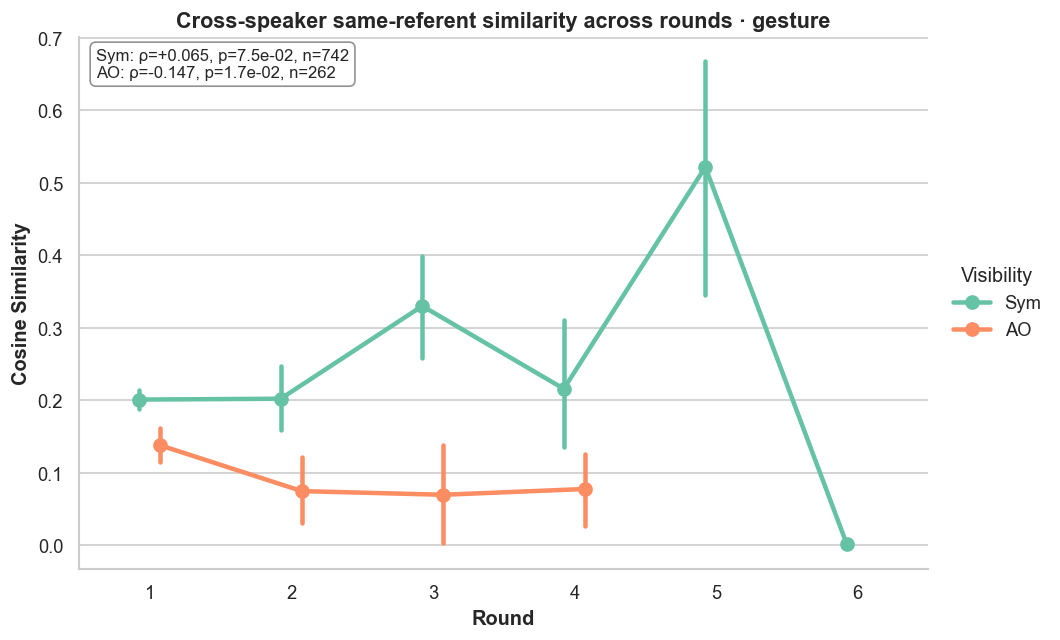

In [82]:
def plot_round_trend(similarities_df, pair_type="Same R &P - diff S", conditions=CONDITIONS):
    """Mean similarity per round for same-round pairs, split by visibility condition."""
    df = similarities_df[(similarities_df["pair_type"] == pair_type)
                         & (similarities_df["condition"].isin(conditions))
                         & (similarities_df["round_i"] == similarities_df["round_j"])].copy()
    df = df.dropna(subset=["round_i", "similarity"])
    df["round"] = df["round_i"].astype(int)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.pointplot(data=df, x="round", y="similarity", hue="condition", hue_order=conditions,
                  palette="Set2", dodge=0.15, markers="o", errorbar=("ci", 95), ax=ax)

    lines = []
    for condition in conditions:
        sub = df[df["condition"] == condition]
        if len(sub) > 2:
            rho, p_val = spearmanr(sub["round"], sub["similarity"])
            lines.append(f"{condition}: ρ={rho:+.3f}, p={p_val:.1e}, n={len(sub):,}")
    ax.text(0.02, 0.98, "\n".join(lines), transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="gray", alpha=0.85))

    ax.set_xlabel("Round", fontweight="bold", fontsize=12)
    ax.set_ylabel("Cosine Similarity", fontweight="bold", fontsize=12)
    ax.set_title(f"Cross-speaker same-referent similarity across rounds · {MODALITY}",
                 fontsize=13, fontweight="bold")
    ax.legend(title="Visibility", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()
    return df


round_df = plot_round_trend(similarities_df)

## 📝 Exercise — compare modalities, models & conditions

Set `MODALITY` (and optionally `PLOT_CONDITION`) below, then re-run the cell to regenerate the intrinsic
similarity plots.

* **MODALITY**: `'gesture'`, `'semantic'`, or `'multimodal'`.
* **PLOT_CONDITION**: `'Sym'`, `'AO'`, `'Asym'`, or `None` for all conditions pooled.

Questions worth asking while you flip the switches:

1. Which effects are carried by the **gestures** and which by the **speech**? (`'gesture'` vs `'semantic'`)
2. Does the cross-speaker, same-referent advantage (H1b) shrink in **AO**, where nobody can see a gesture?
3. Is the *speaker* effect (H2) stable across conditions — i.e. is idiosyncratic style unaffected by
   visibility?
4. What happens to the cross-dialogue baseline (H3)? It should not care about visibility at all.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same P&R&S vs. Same P&S - Diff R: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=5.101e+01


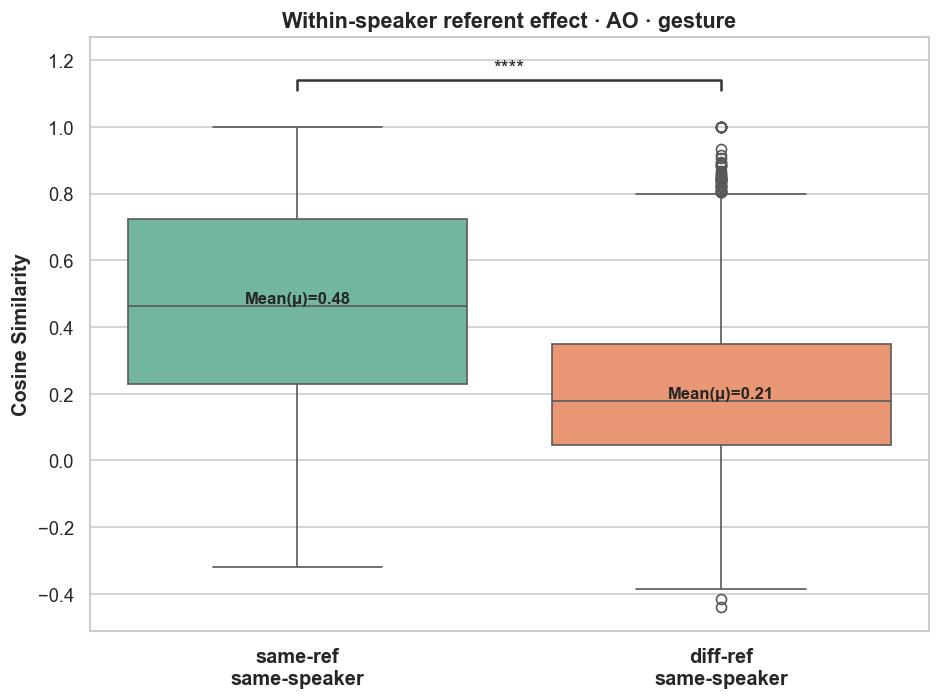

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same P&R&S vs. Same P&S - Diff R: t-test independent samples with Bonferroni correction, P_val:7.506e-248 t=3.560e+01
Same R &P - diff S vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:1.648e-13 t=7.578e+00
Same P&S - Diff R vs. Same R &P - diff S: t-test independent samples with Bonferroni correction, P_val:2.315e-23 t=1.015e+01
Same P&S - Diff R vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:5.803e-59 t=1.649e+01


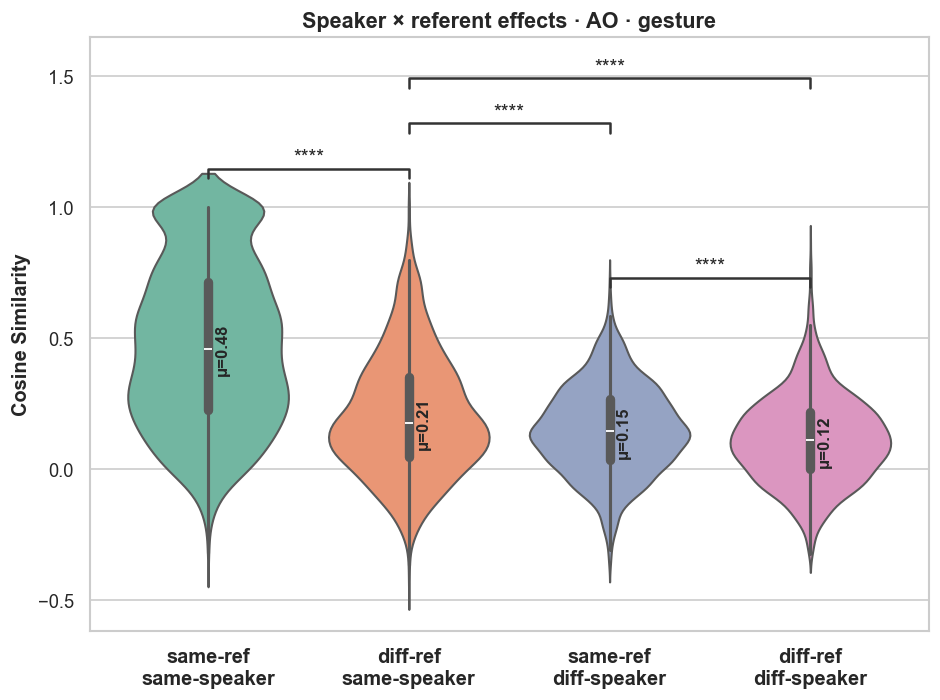

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same R &P - diff S vs. Same R - Diff P&S: t-test independent samples with Bonferroni correction, P_val:4.377e-10 t=-6.411e+00
Same P - Diff R&S vs. Diff P&R&S: t-test independent samples with Bonferroni correction, P_val:6.923e-278 t=-3.565e+01
Same R - Diff P&S vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=6.417e+01


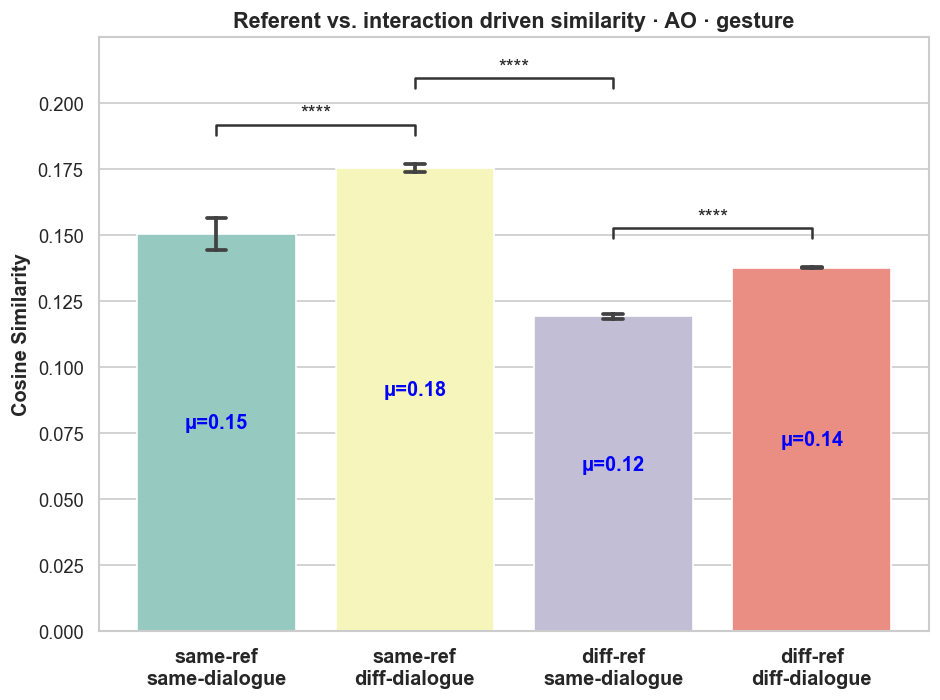

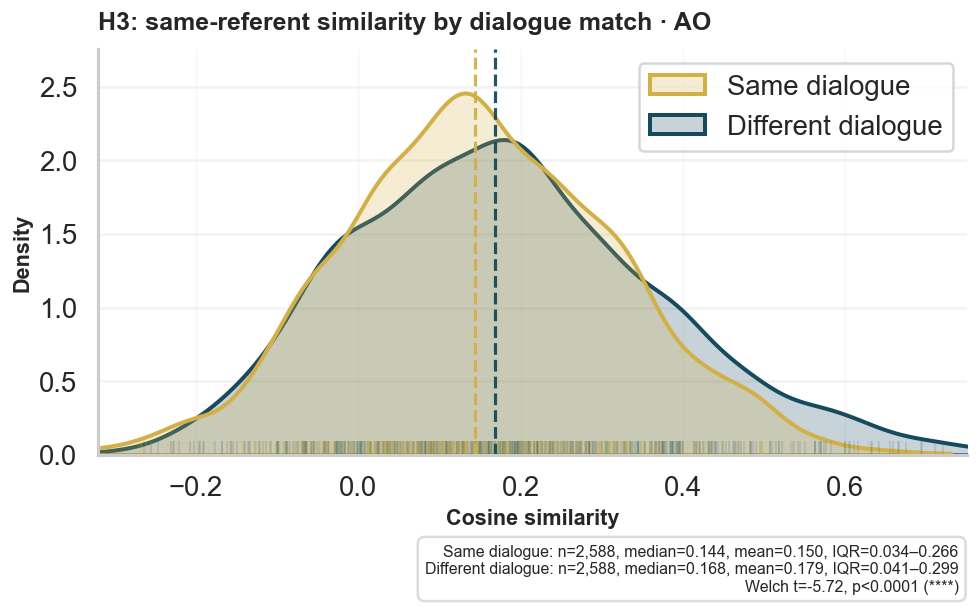

,n_Sym,mean_Sym,n_AO,mean_AO,diff,welch_t,p,sig
pair_type,,,,,,,,
Same P&R&S,7260,0.4764,5232,0.4787,-0.0023,-0.3894,0.697,n.s.
Same P&S - Diff R,269312,0.1782,207946,0.2101,-0.0319,-49.6681,0.000,****
Same R &P - diff S,5492,0.2124,2588,0.1505,0.0619,14.2632,0.000,****
Same P - Diff R&S,252085,0.1257,123399,0.1191,0.0066,10.9687,0.000,****
Same R - Diff P&S,107532,0.1572,60214,0.1753,-0.0181,-18.1265,0.000,****
Diff P&R&S,5622349,0.1068,3268607,0.1375,-0.0307,-250.2029,0.000,****


In [85]:
### ↘️ edit here and re-run ################################################
MODALITY       = "gesture"     # 'gesture' | 'semantic' | 'multimodal'
PLOT_CONDITION = "AO"         # 'Sym' | 'AO' | 'Asym' | None
###########################################################################

sim_mat = compute_cosine_similarity(analysis_df, GESTURE_KEY, modality=MODALITY)
similarities_df = create_pairs_df_for_comparisons(analysis_df, sim_mat)

plot_same_speaker_similarity(similarities_df, subsample=True, condition=PLOT_CONDITION)
plot_cross_speaker_similarity(similarities_df, subsample=True, condition=PLOT_CONDITION)
plot_cross_dialogue_similarity(similarities_df, subsample=False, condition=PLOT_CONDITION)
plot_h3_same_ref_same_vs_diff_dialogue_kde(similarities_df, condition=PLOT_CONDITION)
display(condition_stats(similarities_df).round(4))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same P&R&S vs. Same P&S - Diff R: t-test independent samples with Bonferroni correction, P_val:1.648e-94 t=2.084e+01


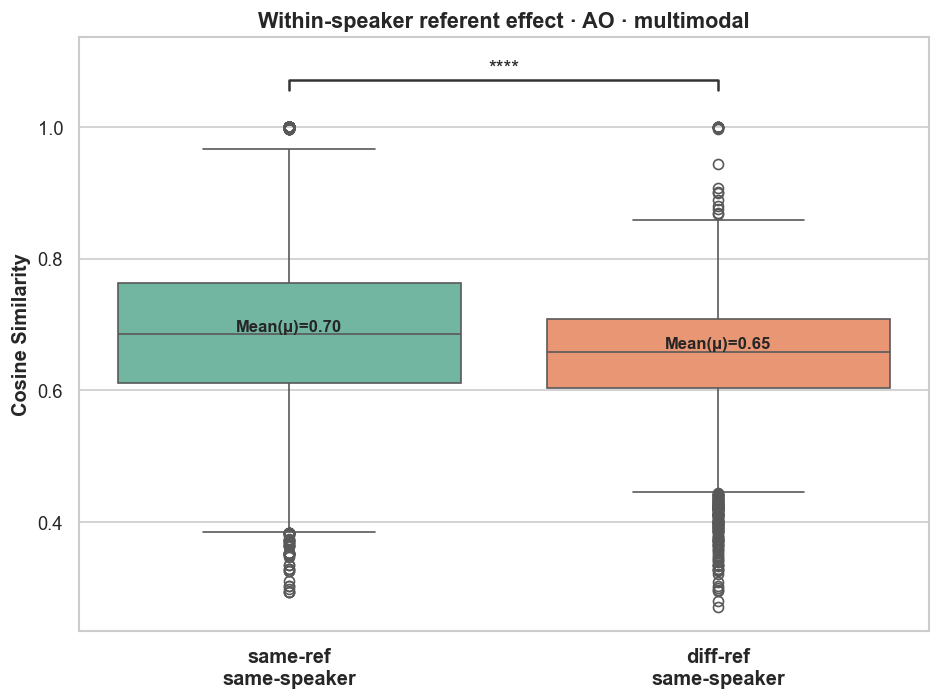

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same P&R&S vs. Same P&S - Diff R: t-test independent samples with Bonferroni correction, P_val:6.506e-50 t=1.511e+01
Same P&S - Diff R vs. Same R &P - diff S: t-test independent samples with Bonferroni correction, P_val:7.308e-05 t=-4.289e+00
Same P&S - Diff R vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:1.256e-02 t=-2.955e+00


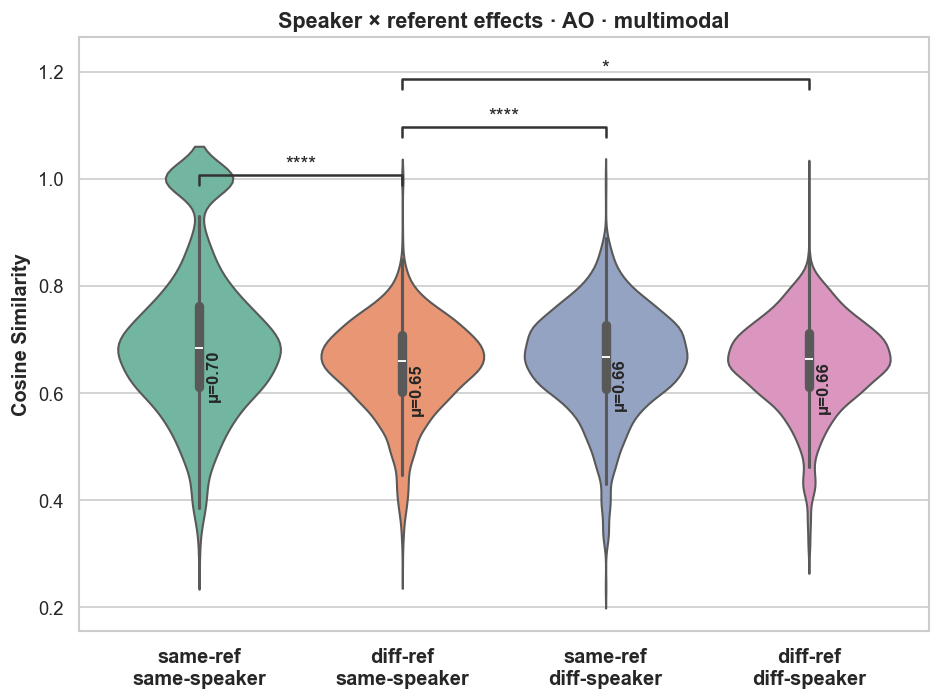

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Same R &P - diff S vs. Same R - Diff P&S: t-test independent samples with Bonferroni correction, P_val:2.962e-15 t=8.031e+00
Same P - Diff R&S vs. Diff P&R&S: t-test independent samples with Bonferroni correction, P_val:0.000e+00 t=5.193e+01
Same R - Diff P&S vs. Same P - Diff R&S: t-test independent samples with Bonferroni correction, P_val:3.524e-80 t=-1.903e+01


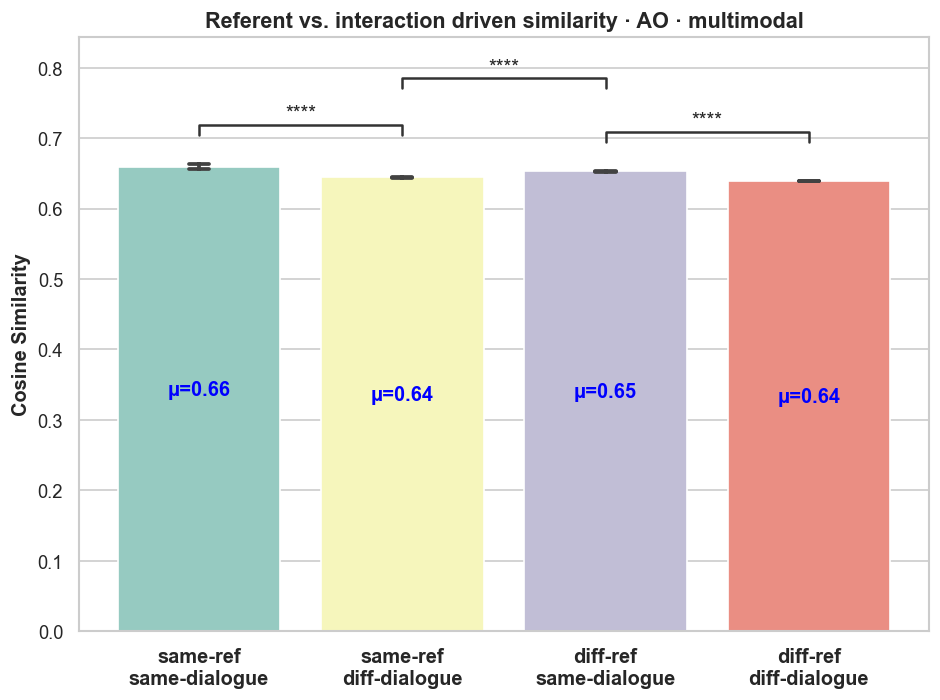

In [86]:
### ↘️ edit here and re-run ################################################
MODALITY       = "multimodal"    # 'gesture' | 'semantic' | 'multimodal'
PLOT_CONDITION = "AO"          # 'Sym' | 'AO' | 'Asym' | None
###########################################################################

sim_mat = compute_cosine_similarity(analysis_df, GESTURE_KEY, modality=MODALITY)
similarities_df = create_pairs_df_for_comparisons(analysis_df, sim_mat)

plot_same_speaker_similarity(similarities_df, subsample=True, condition=PLOT_CONDITION)
plot_cross_speaker_similarity(similarities_df, subsample=True, condition=PLOT_CONDITION)
plot_cross_dialogue_similarity(similarities_df, subsample=False, condition=PLOT_CONDITION)

## 🔟 Conclusion ✨

We reproduced the intrinsic evaluation workflow of Ghaleb et al. (2024, ICMI) on **video-mediated**
dialogue: cosine similarity between contrastively-learned gesture embeddings tracks the semantic content
of a gesture (same referent), the idiosyncratic style of the speaker, and the interactive history of the
dialogue the gesture belongs to — even though the encoder was trained on face-to-face data and applied
here without any fine-tuning.

More importantly, this corpus adds a **manipulation**: because visibility was varied between dyads, the
same pair-type machinery becomes a tool for asking *why* interlocutors' gestures resemble each other.

Finally, we compute **multimodal similarity by concatenating gesture and semantic embeddings**, which can
be used to analyse the interaction between gesture and speech in dialogue.

### Where to go next

* Add the **AsymAV** dyads and test the asymmetry directly: participant B (who can see A) should align more
  than participant A (who cannot see B).
* Move from pairwise tests to a **mixed-effects model** with random intercepts for dyad, speaker and
  referent — the pairwise t-tests here treat non-independent pairs as independent observations, which is
  fine for a tutorial but not for a paper.